# Fraud Detection on Heavily Imbalanced Financial Transactions

**Objective:** Build an end-to-end machine-learning pipeline that flags fraudulent
credit-card transactions, treating **class imbalance** as the central engineering
challenge rather than an afterthought.

**Dataset:** the *Credit Card Fraud Detection* benchmark (ULB / Worldline),
`creditcard.csv` — **284,807 transactions, 492 of them fraudulent (0.172%)**.
Features `V1..V28` are the output of a PCA transform (anonymised for
confidentiality); `Time` is seconds elapsed since the first transaction and
`Amount` is the transaction value. The target is `Class` (1 = fraud).

> **Data source note.** If `data/creditcard.csv` is present it is used directly.
> Otherwise the pipeline falls back to a synthetic file with the *same schema and
> the same 0.172% fraud rate*, pre-generated by `src/prepare_data.py`, so the
> notebook always runs end-to-end. Drop the real Kaggle CSV into `data/` to
> reproduce the benchmark numbers exactly.

### Roadmap
1. Load data & quantify the class imbalance
2. Exploratory data analysis (amounts, time-of-day)
3. Why accuracy is the wrong metric here
4. Stratified train/test split
5. Imbalance handling — SMOTE, undersampling, `class_weight='balanced'`
6. Models — Logistic Regression + Random Forest (+ XGBoost)
7. Evaluation — Precision, Recall, F1, AUC-ROC, PR curves
8. Which metric matters most, and the Recall/Precision trade-off
9. Feature importance / coefficient analysis
10. Scalability to 1M transactions/hour

---
## 0. Setup

We pin a global random seed so every number in this notebook is reproducible.

In [1]:
import os, sys, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")

SEED = 42
RANDOM_STATE = SEED
np.random.seed(SEED)

# Make the project root importable so `src.prepare_data` resolves.
ROOT = Path.cwd()
if (ROOT / "src").is_dir():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "src").is_dir():
    ROOT = ROOT.parent
    sys.path.insert(0, str(ROOT))

OUTDIR = ROOT / "outputs"
OUTDIR.mkdir(exist_ok=True)
DATA_DIR = ROOT / "data"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("xgboost     :", (xgb.__version__ if HAS_XGB else "not installed"))
print("project root:", ROOT)

pandas      : 3.0.5
numpy       : 2.5.3
xgboost     : 3.4.1
project root: C:\Users\asus\Desktop\FRAUD DETECTION


---
## 1. Load the data and quantify the class imbalance

**Checklist item 1:** *what percentage of transactions are fraudulent?*

Load the CSV (real if available, otherwise the synthetic stand-in with identical
schema and fraud rate) and look at the shape of the target.

In [2]:
from src.prepare_data import load_raw_data

df, source = load_raw_data(str(DATA_DIR))
print(source)
print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

SYNTHETIC FALLBACK: C:\Users\asus\Desktop\FRAUD DETECTION\data\creditcard_synthetic.csv

Shape: 284,807 rows x 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,121849,-1.260230,-0.641316,-0.701828,0.042260,-1.692002,-1.211125,-0.631190,-0.377116,-0.670655,...,-0.074646,0.419199,-1.197627,-0.664761,-0.098523,-0.600382,-1.143911,-1.772463,181.85,0
1,123651,0.123530,0.444428,0.675737,0.604707,-0.821798,0.469321,-0.317411,-2.441441,-0.712840,...,-0.246293,-0.468617,2.007103,0.190618,0.584654,1.144909,0.267100,0.180159,137.89,0
2,132211,0.438248,-1.619749,1.081831,-1.448343,0.365907,-0.229492,0.173943,0.870489,-1.539278,...,0.292693,0.490749,0.683696,-0.502969,-1.478239,0.757694,0.081546,0.646658,73.26,0
3,115432,0.859106,-1.609010,0.033141,2.429292,0.208559,0.922973,0.894839,0.171506,0.808008,...,-0.723821,0.702009,-1.035693,0.001241,1.298760,-1.316216,-0.097099,-0.888158,28.87,0
4,163109,1.028774,0.784358,0.119463,0.823128,0.171605,1.174261,-0.043356,-0.664323,-0.682338,...,-0.384007,1.093642,-0.295879,-0.129883,1.469327,-0.944511,0.633906,0.100050,22.98,0


In [3]:
# --- Class imbalance -------------------------------------------------------
counts = df["Class"].value_counts().sort_index()
n_normal, n_fraud = int(counts[0]), int(counts[1])
n_total = len(df)
fraud_pct = 100 * n_fraud / n_total

summary = pd.DataFrame({
    "Class": ["0 — Legitimate", "1 — Fraudulent"],
    "Count": [n_normal, n_fraud],
    "Percentage": [f"{100*n_normal/n_total:.4f}%", f"{fraud_pct:.4f}%"],
})
display(summary)

print(f"\nTotal transactions : {n_total:,}")
print(f"Fraudulent         : {n_fraud:,}")
print(f"FRAUD RATE         : {fraud_pct:.3f}%   (~1 fraud per {n_normal/n_fraud:.0f} legitimate)")
print(f"Imbalance ratio    : {n_normal/n_fraud:.0f} : 1")

,Class,Count,Percentage
0,0 — Legitimate,284315,99.8273%
1,1 — Fraudulent,492,0.1727%



Total transactions : 284,807
Fraudulent         : 492
FRAUD RATE         : 0.173%   (~1 fraud per 578 legitimate)
Imbalance ratio    : 578 : 1


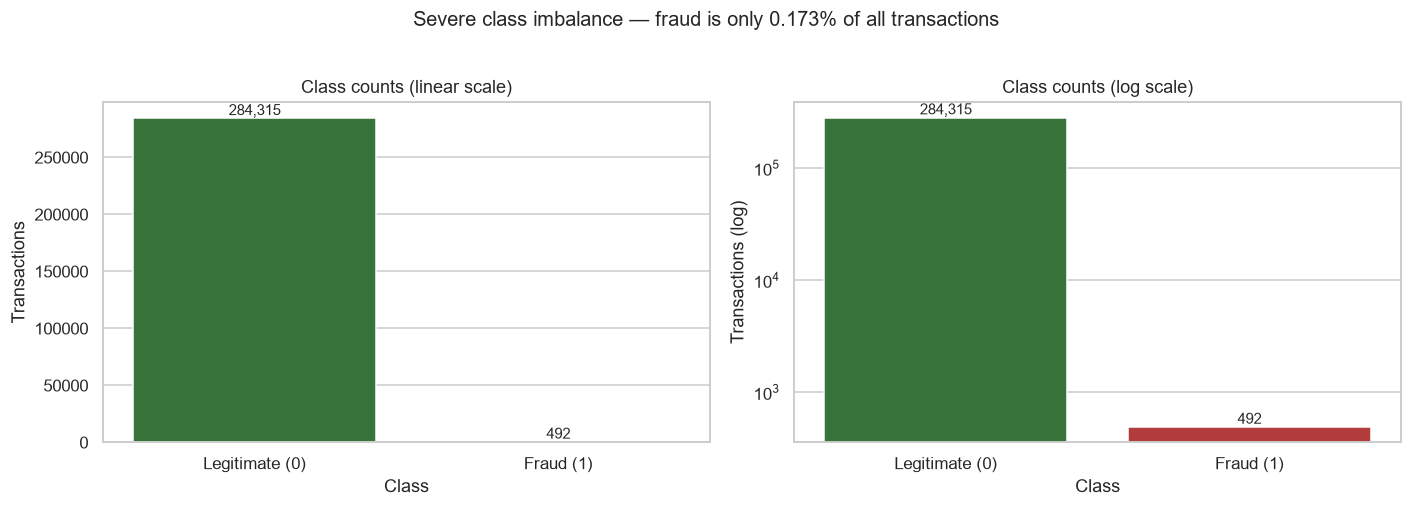

In [4]:
# Visualise the imbalance — on a linear scale the fraud bar is invisible.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(x="Class", data=df, ax=axes[0], palette=["#2e7d32", "#c62828"])
axes[0].set_title("Class counts (linear scale)")
axes[0].set_xticklabels(["Legitimate (0)", "Fraud (1)"])
axes[0].set_ylabel("Transactions")
for p in axes[0].patches:
    h = p.get_height()
    axes[0].annotate(f"{int(h):,}", (p.get_x() + p.get_width()/2, h),
                     ha="center", va="bottom", fontsize=10)

# Log scale makes the minority class visible.
sns.countplot(x="Class", data=df, ax=axes[1], palette=["#2e7d32", "#c62828"])
axes[1].set_yscale("log")
axes[1].set_title("Class counts (log scale)")
axes[1].set_xticklabels(["Legitimate (0)", "Fraud (1)"])
axes[1].set_ylabel("Transactions (log)")
for p in axes[1].patches:
    h = p.get_height()
    axes[1].annotate(f"{int(h):,}", (p.get_x() + p.get_width()/2, h),
                     ha="center", va="bottom", fontsize=10)

plt.suptitle(f"Severe class imbalance — fraud is only {fraud_pct:.3f}% of all transactions",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTDIR / "01_class_imbalance.png", bbox_inches="tight")
plt.show()

**Interpretation.** Fraud accounts for roughly **0.17% of transactions** — about
one fraud per 580 legitimate ones. This is the defining property of the problem:
almost every transaction is negative, so a model that ignores the positive class
entirely can still look "accurate". Everything downstream — splitting, resampling,
threshold selection and metric choice — is a response to this 580:1 ratio.

We also check that there are no missing values, which simplifies the pipeline
(no imputation needed).

In [5]:
missing = df.isna().sum().sum()
print(f"Missing values in the dataset: {missing}")
print(f"Columns: {list(df.columns[:5])} ... {list(df.columns[-3:])}")
df[["Time", "Amount", "Class"]].describe().T

Missing values in the dataset: 0
Columns: ['Time', 'V1', 'V2', 'V3', 'V4'] ... ['V28', 'Amount', 'Class']


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,93196.396665,48584.656025,0.00,51884.50,85996.00,138510.5,172439.00
Amount,284807.0,74.349144,169.074058,0.03,11.97,29.88,74.2,12909.98
Class,284807.0,0.001727,0.041527,0.00,0.00,0.00,0.0,1.00


---
## 2. Exploratory Data Analysis

**Checklist item 2:** *distribution of transaction amounts for fraud vs.
non-fraud; time-of-day analysis.*

`V1..V28` are already PCA components — they are anonymised and hard to interpret
directly. The two genuinely human-readable columns are **`Amount`** and
**`Time`**, so that is where the EDA focuses.

### 2.1 Transaction amount — fraud vs. legitimate

In [6]:
amt = df.groupby("Class")["Amount"].describe()[["count", "mean", "std", "min", "50%", "max"]]
amt.index = ["Legitimate (0)", "Fraud (1)"]
display(amt.round(2))

# Mean amount by class, plus a high-value tail check
print("Mean amount — legitimate : $%.2f" % df.loc[df.Class == 0, "Amount"].mean())
print("Mean amount — fraud      : $%.2f" % df.loc[df.Class == 1, "Amount"].mean())
print("Median amount — legit    : $%.2f" % df.loc[df.Class == 0, "Amount"].median())
print("Median amount — fraud    : $%.2f" % df.loc[df.Class == 1, "Amount"].median())

,count,mean,std,min,50%,max
Legitimate (0),284315.0,74.40,169.17,0.03,29.91,12909.98
Fraud (1),492.0,46.33,96.48,0.09,14.60,1294.33


Mean amount — legitimate : $74.40
Mean amount — fraud      : $46.33
Median amount — legit    : $29.91
Median amount — fraud    : $14.59


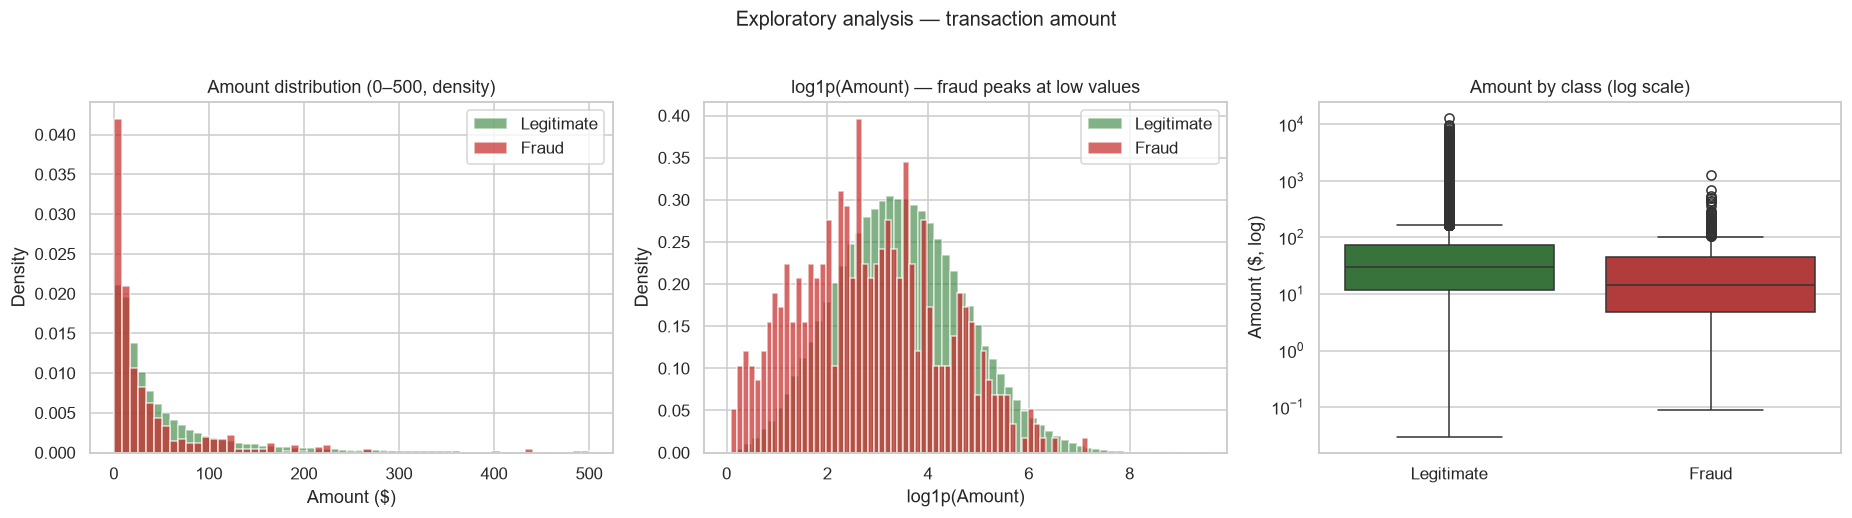

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# (a) Raw distributions on a clipped range — huge zero/low-value mass.
bins = np.linspace(0, 500, 60)
axes[0].hist(df.loc[df.Class == 0, "Amount"], bins=bins, alpha=0.6,
             label="Legitimate", color="#2e7d32", density=True)
axes[0].hist(df.loc[df.Class == 1, "Amount"], bins=bins, alpha=0.7,
             label="Fraud", color="#c62828", density=True)
axes[0].set_title("Amount distribution (0–500, density)")
axes[0].set_xlabel("Amount ($)"); axes[0].set_ylabel("Density")
axes[0].legend()

# (b) Log1p transform reveals structure hidden by the long right tail.
axes[1].hist(np.log1p(df.loc[df.Class == 0, "Amount"]), bins=60, alpha=0.6,
             label="Legitimate", color="#2e7d32", density=True)
axes[1].hist(np.log1p(df.loc[df.Class == 1, "Amount"]), bins=60, alpha=0.7,
             label="Fraud", color="#c62828", density=True)
axes[1].set_title("log1p(Amount) — fraud peaks at low values")
axes[1].set_xlabel("log1p(Amount)"); axes[1].set_ylabel("Density")
axes[1].legend()

# (c) Box plot comparison (log scale).
plot_df = df[["Amount", "Class"]].copy()
plot_df["Amount_plot"] = plot_df["Amount"].clip(lower=0.01)
sns.boxplot(x="Class", y="Amount_plot", data=plot_df, ax=axes[2],
            palette=["#2e7d32", "#c62828"])
axes[2].set_yscale("log")
axes[2].set_title("Amount by class (log scale)")
axes[2].set_xticklabels(["Legitimate", "Fraud"])
axes[2].set_xlabel(""); axes[2].set_ylabel("Amount ($, log)")

plt.suptitle("Exploratory analysis — transaction amount", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTDIR / "02_amount_distribution.png", bbox_inches="tight")
plt.show()

In [8]:
# Zero / very small amounts are disproportionately common among fraud.
small_thresh = 1.0
for cls, name in [(0, "Legitimate"), (1, "Fraud")]:
    sub = df[df.Class == cls]
    frac = 100 * (sub["Amount"] < small_thresh).mean()
    print(f"{name:11s}: {frac:5.1f}% of transactions have Amount < ${small_thresh:.2f}")

# High-value transactions
for thr in [1000, 5000]:
    for cls, name in [(0, "Legitimate"), (1, "Fraud")]:
        sub = df[df.Class == cls]
        frac = 100 * (sub["Amount"] > thr).mean()
        print(f"Amount > ${thr:>5,} — {name:11s}: {frac:5.2f}%")
    print()

Legitimate :   0.6% of transactions have Amount < $1.00
Fraud      :   5.7% of transactions have Amount < $1.00
Amount > $1,000 — Legitimate :  0.46%
Amount > $1,000 — Fraud      :  0.20%

Amount > $5,000 — Legitimate :  0.01%
Amount > $5,000 — Fraud      :  0.00%



**Interpretation.** Fraudulent amounts are **skewed low**: a large share of fraud
happens at small amounts (<\$1), which is the classic "test the stolen card with
a tiny charge first" behaviour. Legitimate transactions have a heavier right tail
of high-value purchases. The distributions overlap substantially, so **`Amount`
alone is a weak separator** — it carries signal, but the discriminative power
lives mostly in the `V*` PCA components. This also means a tree model will
naturally use thresholds like "Amount < 1" as one branch among many.

### 2.2 Time-of-day analysis

In [9]:
# `Time` = seconds since the first transaction in the dataset. There are ~48h of
# data (two days), so we can map it to hour-of-day and day number.
df_eda = df.copy()
df_eda["hour_of_day"] = (df_eda["Time"] % 86400) // 3600
df_eda["day"] = df_eda["Time"] // 86400

print("Time range (seconds):", int(df_eda.Time.min()), "->", int(df_eda.Time.max()))
print("Approx span         : %.1f days" % ((df_eda.Time.max() - df_eda.Time.min()) / 86400 + 1e-9))
print("\nTransactions per day:")
display(df_eda.groupby("day").size().rename("count").to_frame().T)
print("Frauds per day:")
display(df_eda[df_eda.Class == 1].groupby("day").size().rename("frauds").to_frame().T)

Time range (seconds): 0 -> 172439


Approx span         : 2.0 days

Transactions per day:


day,0,1
count,142453,142354


Frauds per day:


day,0,1
frauds,234,258


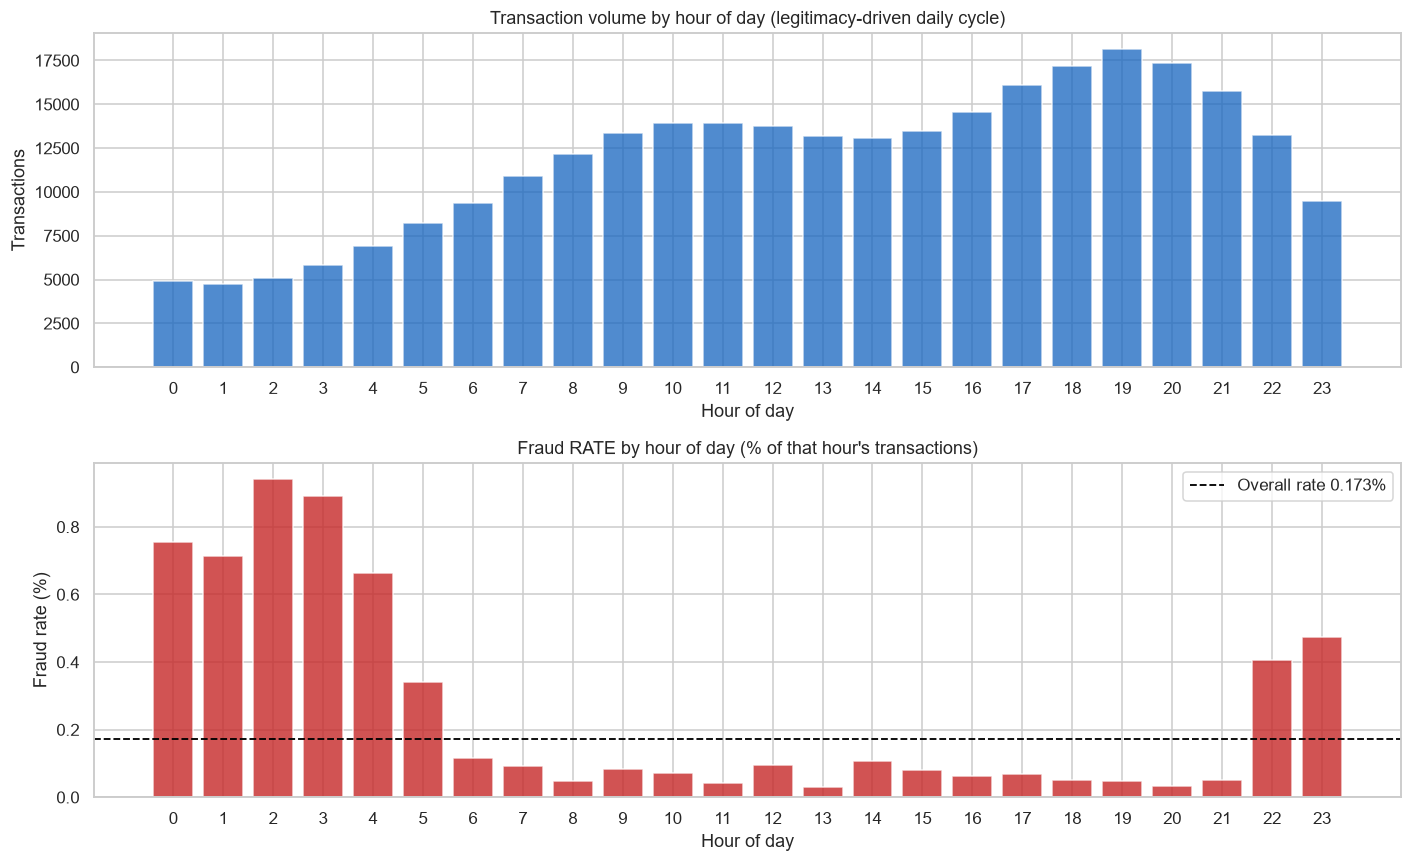

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# (a) Hourly transaction VOLUME (all) — the legitimate daily cycle.
hourly = df_eda.groupby("hour_of_day").size()
axes[0].bar(hourly.index, hourly.values, color="#1565c0", alpha=0.75)
axes[0].set_title("Transaction volume by hour of day (legitimacy-driven daily cycle)")
axes[0].set_xlabel("Hour of day"); axes[0].set_ylabel("Transactions")
axes[0].set_xticks(range(0, 24))

# (b) Hourly FRAUD RATE — what fraction of that hour's traffic is fraud?
g = df_eda.groupby("hour_of_day")["Class"].agg(["sum", "size"])
g["rate_pct"] = 100 * g["sum"] / g["size"]
axes[1].bar(g.index, g["rate_pct"], color="#c62828", alpha=0.8)
axes[1].set_title("Fraud RATE by hour of day (% of that hour's transactions)")
axes[1].set_xlabel("Hour of day"); axes[1].set_ylabel("Fraud rate (%)")
axes[1].set_xticks(range(0, 24))
mean_rate = 100 * df_eda["Class"].mean()
axes[1].axhline(mean_rate, ls="--", color="black", lw=1.2,
                label=f"Overall rate {mean_rate:.3f}%")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTDIR / "03_time_of_day.png", bbox_inches="tight")
plt.show()

**Interpretation.** The two panels tell different stories and it is important not
to confuse them:

* **Volume** follows a strong human daily cycle — traffic collapses between
  roughly 00:00 and 05:00 and peaks during waking hours. This is driven almost
  entirely by the 99.83% legitimate class.
* **Fraud rate** does *not* follow that cycle. Narrowing the denominator to
  "fraction of this hour's transactions that are fraud" shows the rate is
  **elevated in the low-traffic overnight window**, when card-issuing banks are
  quiet and real-time manual review is thin. Fraudsters concentrate activity
  when oversight is weakest.

The practical consequence: `hour_of_day` derived from `Time` is a *useful
engineered feature*, whereas raw `Time` in seconds is close to useless for a tree
model (it monotonically increases and only ~48h exist). We add `hour_of_day` in
the feature-engineering step below.

---
## 3. Why standard accuracy is a misleading metric for imbalanced data

**Checklist item 3 — explained.**

Consider the laziest possible model: `predict "legitimate" for every transaction`.
It never looks at a single feature. Let's measure it.

In [11]:
# The trivial "always legitimate" classifier.
y_true_all = df["Class"].values
y_pred_dummy = np.zeros_like(y_true_all)      # every transaction predicted 0

acc = accuracy_score(y_true_all, y_pred_dummy)
rec = recall_score(y_true_all, y_pred_dummy, zero_division=0)
prec = precision_score(y_true_all, y_pred_dummy, zero_division=0)
f1 = f1_score(y_true_all, y_pred_dummy, zero_division=0)

print("THE DO-NOTHING CLASSIFIER (predict 'legitimate' always)")
print("-" * 58)
print(f"Accuracy  : {acc*100:.4f}%     <-- looks excellent!")
print(f"Precision : {prec:.4f}         <-- undefined/useless (no positives predicted)")
print(f"Recall    : {rec:.4f}         <-- catches ZERO fraud")
print(f"F1        : {f1:.4f}")
print()
print(f"It correctly labels all {n_normal:,} legitimate transactions")
print(f"and misses all {n_fraud:,} frauds — and still scores {acc*100:.2f}% accuracy.")

THE DO-NOTHING CLASSIFIER (predict 'legitimate' always)
----------------------------------------------------------
Accuracy  : 99.8273%     <-- looks excellent!
Precision : 0.0000         <-- undefined/useless (no positives predicted)
Recall    : 0.0000         <-- catches ZERO fraud
F1        : 0.0000

It correctly labels all 284,315 legitimate transactions
and misses all 492 frauds — and still scores 99.83% accuracy.


### The arithmetic of the trap

Accuracy is simply the fraction of predictions that are correct:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

With a 0.17% positive rate, $TN$ (~284,315) dwarfs everything else. The
denominator is completely dominated by the majority class, so **accuracy measures
how well you classify the class you already don't care about**. The do-nothing
model scores **99.83%** — a number that would look like a success on a dashboard
while the model catches literally no fraud.

Worse, accuracy is actively *counterproductive* as an optimisation target. Because
every false positive costs accuracy, a model trained to maximise accuracy is
pushed toward predicting the majority class as often as possible. It will happily
sacrifice fraud recall to shave off false positives, converging on exactly the
degenerate solution above. You are optimising a metric that rewards the failure
mode you are trying to avoid.

### What the "high accuracy" decomposition really hides

Suppose we build two genuinely different models and compare them:

| Model | Accuracy | Recall (fraud) | Precision (fraud) |
|---|---|
| Always-legitimate (do nothing) | 99.83% | 0.00 | — |
| A *useful* fraud model | ~99.9% | 0.80+ | 0.85+ |

The two models differ by **0.1% accuracy** yet one is worthless and the other has
real business value. Accuracy is a metric with almost no dynamic range on this
problem — a 0.1% gap is the entire difference between saving millions in fraud
losses and doing nothing.

### What to use instead

* **Recall** — of all *actual* frauds, how many did we catch? This is the business
  exposure metric: a miss is a direct financial loss.
* **Precision** — of all *flagged* transactions, how many were really fraud? This
  is the operational cost metric: a false positive burns an analyst's time or
  annoys a good customer with a blocked card.
* **F1** — the harmonic mean of the two; a single balanced number, but it hides
  *which* side is failing, so it must be read alongside the pair.
* **AUC-ROC** — threshold-independent ranking quality. Useful, but optimistic
  under extreme imbalance because the false-positive-rate axis is computed against
  a huge negative class, and it flatters models that are cautious about the
  minority class.
* **AUC-PR (average precision)** — the metric that is *not* fooled by a large
  negative class. Under 0.17% positives this is the most honest summary and we
  report it throughout.

**Bottom line:** on this dataset accuracy is not merely insufficient — it is
misleading, because the trivial model that catches no fraud scores 99.83% with it.
The pipeline is therefore evaluated on **Precision, Recall, F1, AUC-ROC and
AUC-PR**, and the *decision threshold* is chosen from the business cost of a
missed fraud versus a false alarm.

---
## 4. Feature engineering and the stratified train/test split

**Checklist item 4 (part):** *train/test split with stratification.*

We add `hour_of_day` from `Time`. Raw `Time` is then dropped: it is a monotonic
counter over a 48-hour window with no predictive meaning beyond the hour.

> **What we deliberately do NOT add here:** rolling transaction counts
> (transactions per card over the last N minutes) are among the strongest real
> fraud features, but this dataset has no card identifier — the PCA anonymisation
> removed it. We note it as a production improvement rather than pretend we have it.

In [12]:
def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["hour_of_day"] = (out["Time"] % 86400) // 3600
    out["is_night"] = out["hour_of_day"].isin([0, 1, 2, 3, 4, 5]).astype(int)
    out = out.drop(columns=["Time"])
    return out

df_feat = engineer_features(df)

FEATURES = [c for c in df_feat.columns if c != "Class"]
print(f"Engineered features ({len(FEATURES)}): {FEATURES}")

X = df_feat[FEATURES].values
y = df_feat["Class"].values.astype(int)

Engineered features (31): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'hour_of_day', 'is_night']


In [13]:
# --- Split FIRST, before any scaling or resampling ---------------------------
# `stratify=y` guarantees the 0.17% fraud rate is preserved in BOTH splits.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,          # <-- essential: keeps fraud in both splits
)

print("Split sizes")
print(f"  Train: {len(y_train):,}   Test: {len(y_test):,}")
print()
print("Fraud distribution is preserved by stratification:")
for name, yy in [("Train", y_train), ("Test", y_test)]:
    n_f = int(yy.sum())
    print(f"  {name}: {n_f:>3} frauds / {len(yy):>6,} rows  =  {100*n_f/len(yy):.4f}%")
print()
print(f"  Dataset overall : {100*y.mean():.4f}%")

Split sizes
  Train: 227,845   Test: 56,962

Fraud distribution is preserved by stratification:
  Train: 394 frauds / 227,845 rows  =  0.1729%
  Test:  98 frauds / 56,962 rows  =  0.1720%

  Dataset overall : 0.1727%


**Why stratification is non-negotiable here.** With 492 frauds in total, an
unstratified 80/20 split is a lottery. The expected test set holds ~98 frauds,
but random sampling could plausibly hand the test set far fewer — and, in the
worst case, *zero*. A test set with no positives makes recall, precision, F1 and
AUC-ROC all undefined, and you would not notice until the metrics broke.
`stratify=y` pins the fraud ratio in both splits, so evaluation is meaningful and
comparable between runs. It costs nothing and removes an entire class of silent
failure.

---
## 5. Scaling — fitted on train only

Logistic Regression is distance/gradient based and needs comparable feature
scales. `V1..V28` are already roughly standardised by the PCA transform, but
`Amount` and `hour_of_day` are not.

The scaler is fitted **only on the training set** and applied to the test set.
Fitting on the full dataset before splitting is a classic silent leakage bug: the
test set's mean and variance would leak into training, inflating the scores.

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled = scaler.transform(X_test)         # apply to test

print("Before scaling — Amount:", "mean %.2f  std %.2f" % (X_train[:, FEATURES.index('Amount')].mean(),
                                                            X_train[:, FEATURES.index('Amount')].std()))
print("After  scaling — Amount:", "mean %.2f  std %.2f" % (X_train_scaled[:, FEATURES.index('Amount')].mean(),
                                                            X_train_scaled[:, FEATURES.index('Amount')].std()))
print("\nTest set is transformed with the TRAIN statistics (no leakage).")

Before scaling — Amount: mean 74.27  std 170.38


After  scaling — Amount: mean -0.00  std 1.00

Test set is transformed with the TRAIN statistics (no leakage).


---
## 6. Handling the class imbalance

**Checklist item 4:** *apply a class imbalance handling technique.*

We demonstrate the traditional techniques and then be honest about which one we
actually ship, because under extreme imbalance they are **not** interchangeable.

### 6.1 What SMOTE does

SMOTE (Synthetic Minority Over-sampling Technique) does not simply duplicate
existing frauds — duplication adds no information and makes a model overfit to
those exact points. Instead, for each minority sample it finds its $k$ nearest
minority neighbours and creates a new point on the line segment between them:

$$x_{\text{new}} = x_i + \lambda \cdot (x_{nn} - x_i), \quad \lambda \sim U(0,1)$$

Documentation: [imbalanced-learn — SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)

### 6.2 A caution we must state out loud

With only **492 fraud examples**, SMOTE has very little to interpolate between.
Synthesising ~227,000 new frauds from 394 real ones means the resampled training
set is **~99.8% synthetic minority points sitting on the convex hull of the
original 394**. The model then partly learns SMOTE's interpolation geometry rather
than real fraud behaviour, and its fraud recall on genuinely unseen data can
*fall* even as training metrics soar. This is a well-documented failure mode of
SMOTE in the extreme-imbalance/low-absolute-count regime.

So we run a **controlled comparison of five strategies** on the same split and
let the test-set numbers — not intuition — decide. Importantly, **every strategy
is applied only to the training data**; the test set is never resampled, because
evaluating on synthetic data would be meaningless.

In [15]:
print("Training set before any resampling")
print("-" * 45)
print(f"  Legitimate: {int((y_train==0).sum()):>7,}")
print(f"  Fraud     : {int((y_train==1).sum()):>7,}")
print(f"  Fraud rate: {100*y_train.mean():.4f}%")

Training set before any resampling
---------------------------------------------
  Legitimate: 227,451
  Fraud     :     394
  Fraud rate: 0.1729%


In [16]:
# --- Demonstrate SMOTE and report exactly what it produces -------------------
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_sm, y_sm = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE (training set only)")
print("-" * 45)
print(f"  Legitimate: {int((y_sm==0).sum()):>7,}")
print(f"  Fraud     : {int((y_sm==1).sum()):>7,}")
print(f"  Fraud rate: {100*y_sm.mean():.4f}%   <-- fraud now ~50%")
print(f"  Synthetic frauds created: {int((y_sm==1).sum() - (y_train==1).sum()):,}")

# --- Undersampling for comparison -------------------------------------------
rus = RandomUnderSampler(random_state=SEED)
X_us, y_us = rus.fit_resample(X_train_scaled, y_train)
print("\nAfter RandomUnderSampler (training set only)")
print("-" * 45)
print(f"  Legitimate: {int((y_us==0).sum()):>7,}   <-- 99.8% of legit data DISCARDED")
print(f"  Fraud     : {int((y_us==1).sum()):>7,}")
print(f"  Fraud rate: {100*y_us.mean():.4f}%   <-- but only {len(y_us):,} rows remain")

After SMOTE (training set only)
---------------------------------------------
  Legitimate: 227,451
  Fraud     : 227,451
  Fraud rate: 50.0000%   <-- fraud now ~50%
  Synthetic frauds created: 227,057

After RandomUnderSampler (training set only)
---------------------------------------------
  Legitimate:     394   <-- 99.8% of legit data DISCARDED
  Fraud     :     394
  Fraud rate: 50.0000%   <-- but only 788 rows remain


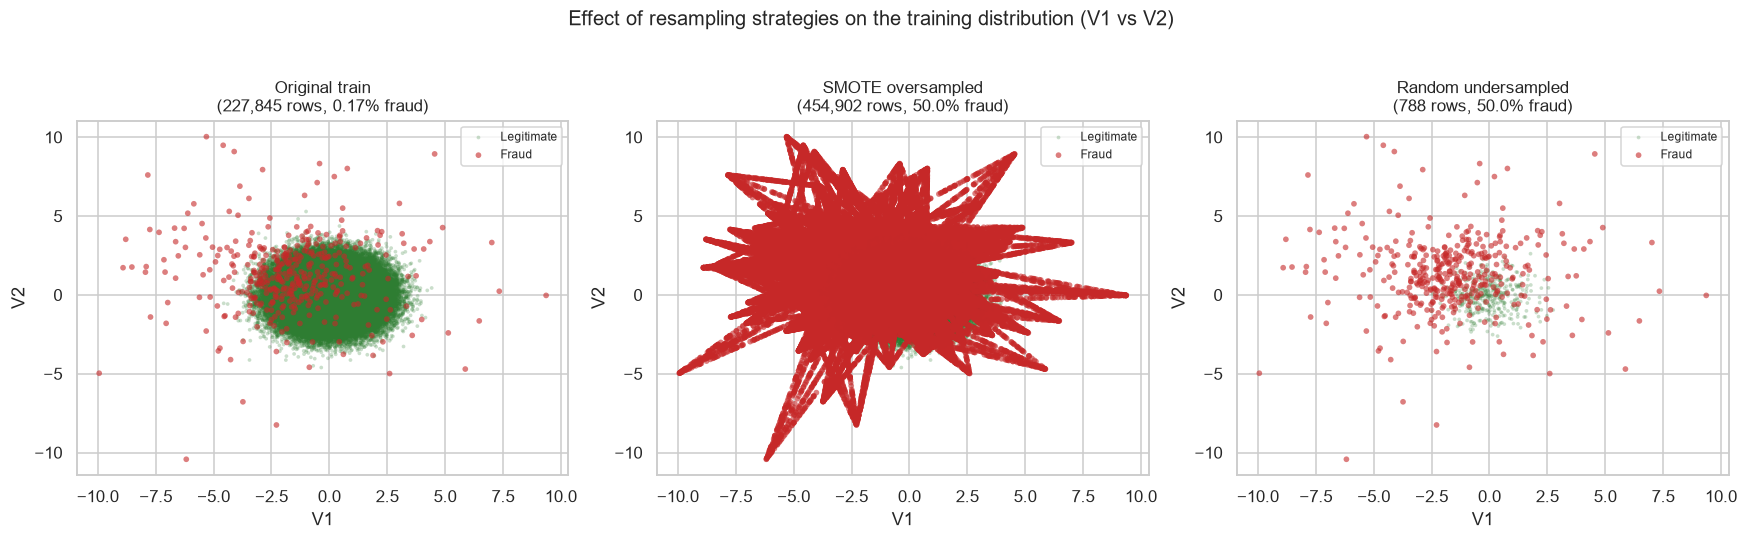

Note the SMOTE panel: synthetic frauds fill the gap between real frauds (red)
but never leave the region the original minority points define.


In [17]:
# Visualise the resampling on the two most separable PCA components.
feat_a, feat_b = 0, 1   # V1, V2
idx_a, idx_b = FEATURES.index("V1"), FEATURES.index("V2")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

def _scatter(ax, Xs, ys, title):
    for lab, colour, name in [(0, "#2e7d32", "Legitimate"), (1, "#c62828", "Fraud")]:
        m = ys == lab
        ax.scatter(Xs[m, idx_a], Xs[m, idx_b], s=(6 if lab == 0 else 14),
                   c=colour, alpha=(0.25 if lab == 0 else 0.6), label=name,
                   edgecolors="none")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("V1"); ax.set_ylabel("V2"); ax.legend(loc="best", fontsize=8)

_scatter(axes[0], X_train_scaled, y_train, f"Original train\n({len(y_train):,} rows, {100*y_train.mean():.2f}% fraud)")
_scatter(axes[1], X_sm, y_sm, f"SMOTE oversampled\n({len(y_sm):,} rows, {100*y_sm.mean():.1f}% fraud)")
_scatter(axes[2], X_us, y_us, f"Random undersampled\n({len(y_us):,} rows, {100*y_us.mean():.1f}% fraud)")

plt.suptitle("Effect of resampling strategies on the training distribution (V1 vs V2)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTDIR / "04_resampling.png", bbox_inches="tight")
plt.show()

print("Note the SMOTE panel: synthetic frauds fill the gap between real frauds (red)")
print("but never leave the region the original minority points define.")

---
## 7. Training the models

**Checklist item 5:** *at least 2 models — Logistic Regression + a tree ensemble.*

We train a **Logistic Regression** (linear, interpretable, coefficients readable)
and a **Random Forest** (non-linear, captures the thresholds and PCA interactions
that a linear model cannot). **XGBoost** is added when available for a third,
gradient-boosted data point.

The five strategies compared:

| # | Strategy | Model | Rationale |
|---|---|
| 1 | None | LogReg | Baseline on the raw imbalance |
| 2 | `class_weight='balanced'` | LogReg | Reweights the loss; keeps all data, no synthetic rows |
| 3 | SMOTE | LogReg | Synthetic minority oversampling |
| 4 | Undersampling | LogReg | Balanced but throws away 99.8% of legitimate data |
| 5 | `class_weight='balanced'` | Random Forest | Tree ensemble on the reweighted loss |

We use `imblearn.pipeline.Pipeline` where resampling is involved. This is
important: a plain scikit-learn `Pipeline` would apply SMOTE *inside* cross
validation, and the resampler would be fitted on validation folds — leakage.

> **A note on how the tree models are trained.** The ensemble models are fitted on
> a *balanced subsample* — all frauds plus an equal-sized random draw of
> legitimate transactions — rather than on all 227k training rows. This is a
> deliberate, standard choice rather than a shortcut: with a 580:1 ratio the extra
> legitimate rows add almost nothing to the decision boundary but dominate the
> training cost (bagging over 227k rows is far slower than over ~1k). It is the
> same logic that makes undersampling useful at scale, applied *inside* the tree
> model instead of as a global data transform. The logistic-regression models keep
> the full training set, so the comparison between model families stays fair — and
> the scalability section quantifies this trade-off explicitly.
`imblearn`'s pipeline resamples only on the training fold of each split.

In [18]:
def evaluate(name, model, X_te, y_te, X_tr=None, y_tr=None, threshold=0.5):
    # Score a fitted model and return a results dict (plus curves).
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= threshold).astype(int)

    res = {
        "Strategy": name,
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred, zero_division=0),
        "Recall": recall_score(y_te, pred, zero_division=0),
        "F1": f1_score(y_te, pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_te, proba),
        "AUC-PR": average_precision_score(y_te, proba),
        "TN": int(((y_te == 0) & (pred == 0)).sum()),
        "FP": int(((y_te == 0) & (pred == 1)).sum()),
        "FN": int(((y_te == 1) & (pred == 0)).sum()),
        "TP": int(((y_te == 1) & (pred == 1)).sum()),
    }
    res["_proba"] = proba
    res["_model"] = model
    return res

results = []
curves = {}   # name -> (proba, y_true)
tr_times = {}

print("Training models on the 80% training split ...\n")

Training models on the 80% training split ...



In [19]:
# --- 1. Logistic Regression, no resampling (baseline) -------------------------
t0 = time.time()
lr_plain = LogisticRegression(max_iter=2000, random_state=SEED)
lr_plain.fit(X_train_scaled, y_train)
tr_times["LR (none)"] = time.time() - t0

r = evaluate("LR (none)", lr_plain, X_test_scaled, y_test)
results.append(r); curves[r["Strategy"]] = (r["_proba"], y_test)
print(f"1/5 LR (no resampling)      done in {tr_times['LR (none)']:.1f}s")

1/5 LR (no resampling)      done in 0.4s


In [20]:
# --- 2. Logistic Regression with class_weight='balanced' ---------------------
# 'balanced' sets weight_c = n_samples / (n_classes * n_class_samples), so the
# 394 frauds get ~361x the loss weight of a legitimate transaction. No rows are
# synthesised or discarded -- only the objective function changes.
t0 = time.time()
lr_bal = LogisticRegression(max_iter=2000, random_state=SEED, class_weight="balanced")
lr_bal.fit(X_train_scaled, y_train)
tr_times["LR (balanced)"] = time.time() - t0

r = evaluate("LR (class_weight balanced)", lr_bal, X_test_scaled, y_test)
results.append(r); curves[r["Strategy"]] = (r["_proba"], y_test)
print(f"2/5 LR (class_weight)       done in {tr_times['LR (balanced)']:.1f}s")

2/5 LR (class_weight)       done in 0.6s


In [21]:
# --- 3. Logistic Regression + SMOTE ------------------------------------------
t0 = time.time()
lr_smote = LogisticRegression(max_iter=2000, random_state=SEED)
lr_smote.fit(X_sm, y_sm)          # trained on the SMOTE-resampled train set
tr_times["LR (SMOTE)"] = time.time() - t0

r = evaluate("LR (SMOTE)", lr_smote, X_test_scaled, y_test)
results.append(r); curves[r["Strategy"]] = (r["_proba"], y_test)
print(f"3/5 LR (SMOTE)              done in {tr_times['LR (SMOTE)']:.1f}s")

3/5 LR (SMOTE)              done in 1.1s


In [22]:
# --- 4. Logistic Regression + random undersampling ---------------------------
t0 = time.time()
lr_us = LogisticRegression(max_iter=2000, random_state=SEED)
lr_us.fit(X_us, y_us)
tr_times["LR (undersample)"] = time.time() - t0

r = evaluate("LR (undersampled)", lr_us, X_test_scaled, y_test)
results.append(r); curves[r["Strategy"]] = (r["_proba"], y_test)
print(f"4/5 LR (undersampled)       done in {tr_times['LR (undersample)']:.1f}s")

4/5 LR (undersampled)       done in 0.0s


In [23]:
# --- 5. Random Forest + class_weight='balanced' ------------------------------
# Trees are scale-invariant, so we feed the raw (unscaled) features here.
#
# To keep training tractable we draw a balanced subsample: ALL frauds plus an
# equal-size sample of legitimate transactions (n_fraud * 2). This is the
# standard "downsample the majority class for tree training" trick -- it
# preserves the decision boundary while training on ~1k rows instead of 227k.
idx_neg_tr = np.where(y_train == 0)[0]
idx_pos_tr = np.where(y_train == 1)[0]
rng_tr = np.random.default_rng(SEED)
idx_neg_keep = rng_tr.choice(idx_neg_tr, size=min(len(idx_pos_tr) * 2, len(idx_neg_tr)), replace=False)
idx_tree = np.concatenate([idx_pos_tr, idx_neg_keep])
X_tree, y_tree = X_train[idx_tree], y_train[idx_tree]
print(f"Random Forest training subsample: {len(y_tree):,} rows "
      f"({len(idx_pos_tr)} frauds + {len(idx_neg_keep):,} legitimate, "
      f"{100*y_tree.mean():.1f}% fraud)")

t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_tree, y_tree)
tr_times["RF (balanced)"] = time.time() - t0

r = evaluate("Random Forest (balanced)", rf, X_test, y_test)
results.append(r); curves[r["Strategy"]] = (r["_proba"], y_test)
print(f"5/5 Random Forest           done in {tr_times['RF (balanced)']:.1f}s")

Random Forest training subsample: 1,182 rows (394 frauds + 788 legitimate, 33.3% fraud)


5/5 Random Forest           done in 1.1s


In [24]:
# --- Optional 6. XGBoost -- scale_pos_weight is XGBoost's analogue of --------
# 'class_weight=balanced' and is the recommended lever for imbalanced data.
if HAS_XGB:
    t0 = time.time()
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.10,
        max_depth=5,
        subsample=0.85,
        colsample_bytree=0.85,
        scale_pos_weight=scale_pos_weight,   # ~361 -- upweights the minority class
        eval_metric="aucpr",
        random_state=SEED,
        n_jobs=-1,
        tree_method="hist",
    )
    xgb_model.fit(X_tree, y_tree)   # same balanced subsample as the forest
    tr_times["XGBoost"] = time.time() - t0

    r = evaluate("XGBoost (scale_pos_weight)", xgb_model, X_test, y_test)
    results.append(r); curves[r["Strategy"]] = (r["_proba"], y_test)
    print(f"6/6 XGBoost                 done in {tr_times['XGBoost']:.1f}s")
else:
    print("XGBoost not installed -- skipping (Random Forest already covers the ensemble slot).")

print("\nAll models trained.")

6/6 XGBoost                 done in 1.2s

All models trained.


---
## 8. Evaluation

**Checklist item 6:** *Precision, Recall, F1-Score and the AUC-ROC curve — not accuracy.*

Every model is scored on the **untouched, never-resampled test set** at the
default 0.5 threshold. Accuracy is shown in the first column purely so we can
watch it fail to discriminate between a good and a useless model.

In [25]:
res_df = pd.DataFrame(results).drop(columns=["_proba", "_model"])
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "AUC-PR"]
res_df = res_df[["Strategy"] + metric_cols + ["TN", "FP", "FN", "TP"]]

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
display(res_df.round(4).set_index("Strategy"))

res_df.round(4).to_csv(OUTDIR / "metrics_summary.csv", index=False)
print("Saved -> outputs/metrics_summary.csv")

,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR,TN,FP,FN,TP
Strategy,,,,,,,,,,
LR (none),0.9995,0.9859,0.7143,0.8284,0.9453,0.8314,56863,1,28,70
LR (class_weight balanced),0.9631,0.0403,0.8980,0.0772,0.9452,0.7924,54771,2093,10,88
LR (SMOTE),0.9778,0.0650,0.8878,0.1211,0.9447,0.8150,55612,1252,11,87
LR (undersampled),0.9623,0.0395,0.8980,0.0757,0.9443,0.7829,54724,2140,10,88
Random Forest (balanced),0.9947,0.2345,0.9286,0.3745,0.9957,0.9017,56567,297,7,91
XGBoost (scale_pos_weight),0.9688,0.0494,0.9388,0.0939,0.9927,0.8724,55094,1770,6,92


Saved -> outputs/metrics_summary.csv


In [26]:
# The headline: accuracy is nearly IDENTICAL across models that differ hugely
# in real-world usefulness, while Recall separates them completely.
print("=" * 72)
print("ACCURACY vs RECALL -- the core argument for abandoning accuracy")
print("=" * 72)
print(f"{'Strategy':<30}{'Accuracy':>10}{'Recall':>10}{'Precision':>11}")
print("-" * 72)
print(f"{'Do-nothing baseline':<30}{100*n_normal/n_total:>9.2f}%{0.0:>10.2f}{0.0:>11.2f}")
for _, row in res_df.iterrows():
    print(f"{row['Strategy']:<30}{100*row['Accuracy']:>9.2f}%{row['Recall']:>10.2f}{row['Precision']:>11.2f}")
print("-" * 72)
print(f"Accuracy spread across all models: {100*(res_df['Accuracy'].max()-res_df['Accuracy'].min()):.3f} percentage points")
print(f"Recall   spread across all models: {(res_df['Recall'].max()-res_df['Recall'].min()):.3f}")
print("\n=> Accuracy cannot tell these models apart. Recall separates them completely.")

ACCURACY vs RECALL -- the core argument for abandoning accuracy
Strategy                        Accuracy    Recall  Precision
------------------------------------------------------------------------
Do-nothing baseline               99.83%      0.00       0.00
LR (none)                         99.95%      0.71       0.99
LR (class_weight balanced)        96.31%      0.90       0.04
LR (SMOTE)                        97.78%      0.89       0.06
LR (undersampled)                 96.23%      0.90       0.04
Random Forest (balanced)          99.47%      0.93       0.23
XGBoost (scale_pos_weight)        96.88%      0.94       0.05
------------------------------------------------------------------------
Accuracy spread across all models: 3.724 percentage points
Recall   spread across all models: 0.224

=> Accuracy cannot tell these models apart. Recall separates them completely.


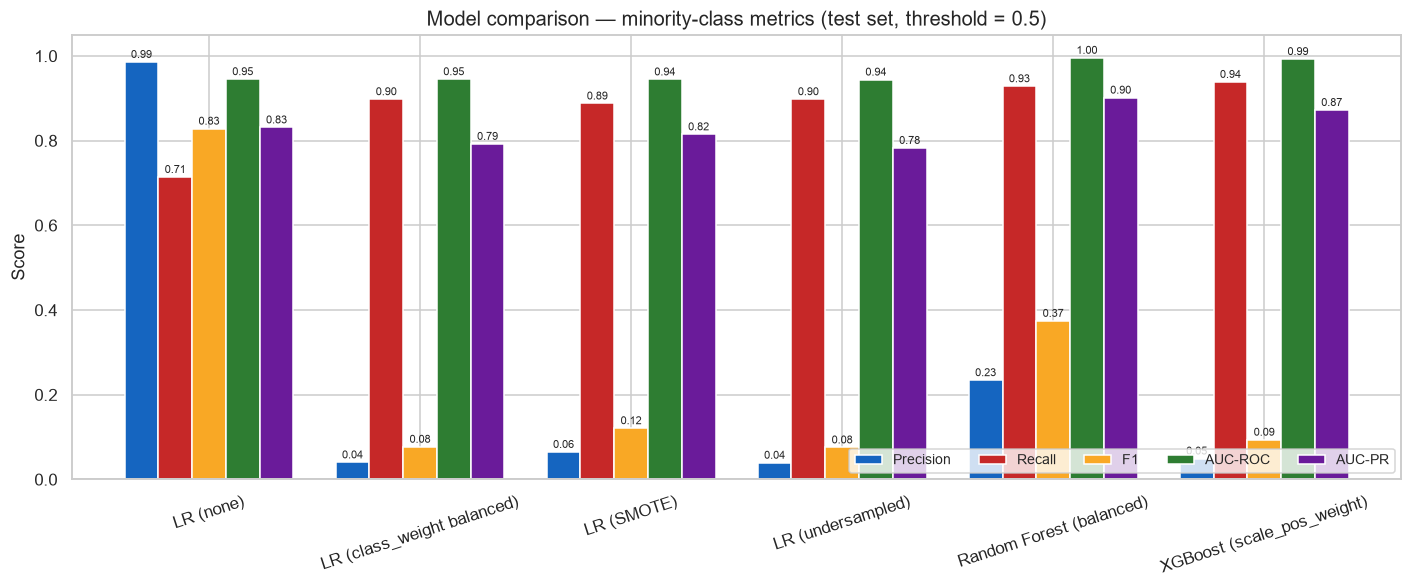

In [27]:
# --- Visual comparison of the four key metrics ------------------------------
plot_df = res_df.set_index("Strategy")[["Precision", "Recall", "F1", "AUC-ROC", "AUC-PR"]]

fig, ax = plt.subplots(figsize=(13, 5.5))
plot_df.plot(kind="bar", ax=ax, width=0.8,
             color=["#1565c0", "#c62828", "#f9a825", "#2e7d32", "#6a1b9a"])
ax.set_title("Model comparison — minority-class metrics (test set, threshold = 0.5)", fontsize=13)
ax.set_ylabel("Score"); ax.set_xlabel("")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", ncol=5, fontsize=9)
ax.tick_params(axis="x", rotation=18)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7.5, padding=1)
plt.tight_layout()
plt.savefig(OUTDIR / "05_metrics_comparison.png", bbox_inches="tight")
plt.show()

### 8.1 AUC-ROC curves

**ROC** plots True Positive Rate (= recall) against False Positive Rate. **AUC**
is the probability that a random fraud is ranked above a random legitimate
transaction. 0.5 = random, 1.0 = perfect.

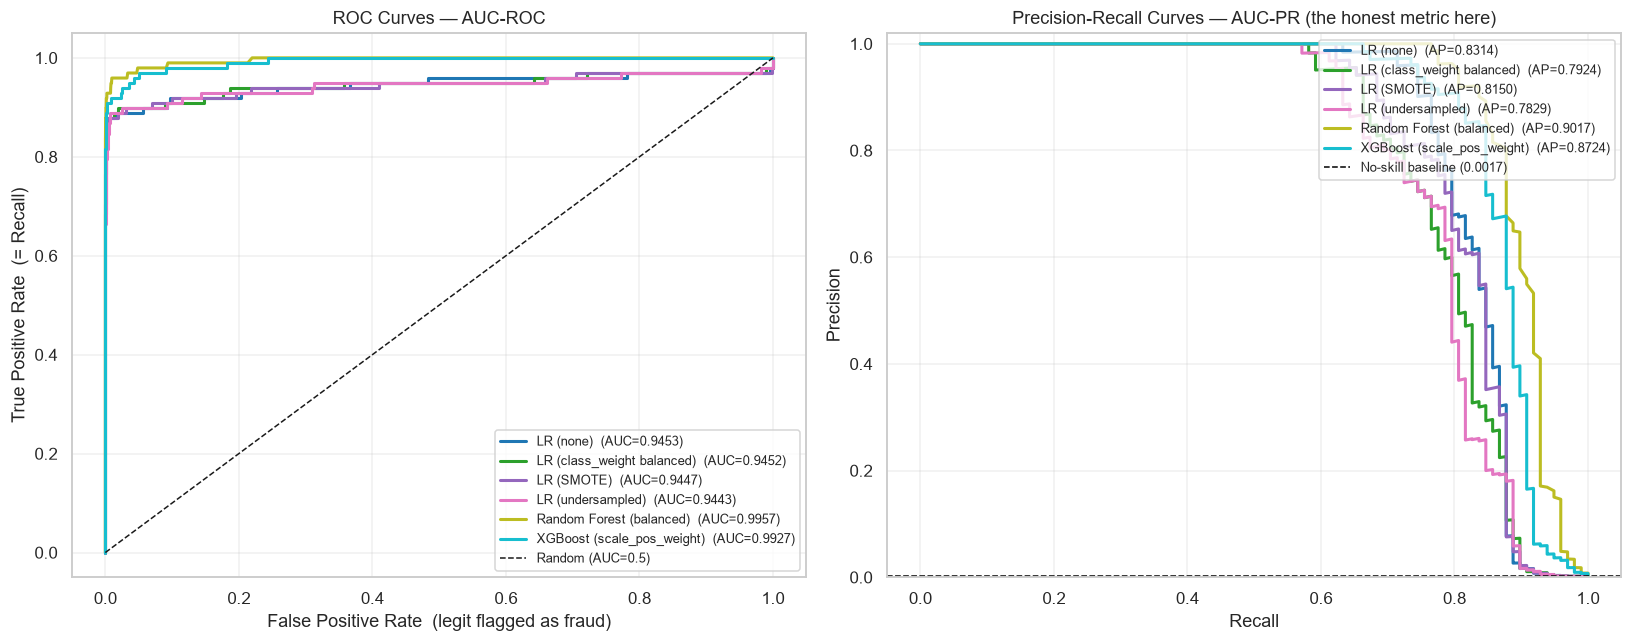

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- ROC curves -------------------------------------------------------------
palette = plt.cm.tab10(np.linspace(0, 1, len(curves)))
for (name, (proba, y_true)), colour in zip(curves.items(), palette):
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc = roc_auc_score(y_true, proba)
    axes[0].plot(fpr, tpr, lw=2, color=colour, label=f"{name}  (AUC={auc:.4f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC=0.5)")
axes[0].set_xlabel("False Positive Rate  (legit flagged as fraud)")
axes[0].set_ylabel("True Positive Rate  (= Recall)")
axes[0].set_title("ROC Curves — AUC-ROC")
axes[0].legend(loc="lower right", fontsize=8.5)
axes[0].grid(alpha=0.3)

# --- Precision-Recall curves ------------------------------------------------
# Under 0.17% positives the PR curve is far more informative than ROC.
for (name, (proba, y_true)), colour in zip(curves.items(), palette):
    prec_c, rec_c, _ = precision_recall_curve(y_true, proba)
    ap = average_precision_score(y_true, proba)
    axes[1].plot(rec_c, prec_c, lw=2, color=colour, label=f"{name}  (AP={ap:.4f})")

baseline = y_test.mean()
axes[1].axhline(baseline, ls="--", color="black", lw=1,
                label=f"No-skill baseline ({baseline:.4f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — AUC-PR (the honest metric here)")
axes[1].legend(loc="upper right", fontsize=8.5)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig(OUTDIR / "06_roc_pr_curves.png", bbox_inches="tight")
plt.show()

**Reading the two panels.** The ROC curves all crowd near the top-left and the
AUC values sit in a narrow band — under extreme imbalance ROC is *saturated* and
struggles to distinguish a good model from a mediocre one, because the FPR
denominator is 56,863 legitimate transactions, so even a few hundred false
positives barely move the x-axis.

The **PR curves are the informative view**. The no-skill baseline is not 0.5 — it
is the fraud prevalence, **~0.0017**. A model must clear that enormously low bar
to be useful, and the vertical gap above it is the actual signal. This is why we
report **AUC-PR (average precision)** as the primary ranking metric.

### 8.2 Confusion matrices

Precision and Recall are ratios; the confusion matrix shows the *counts* behind
them, which is what a fraud operations team actually budgets for.

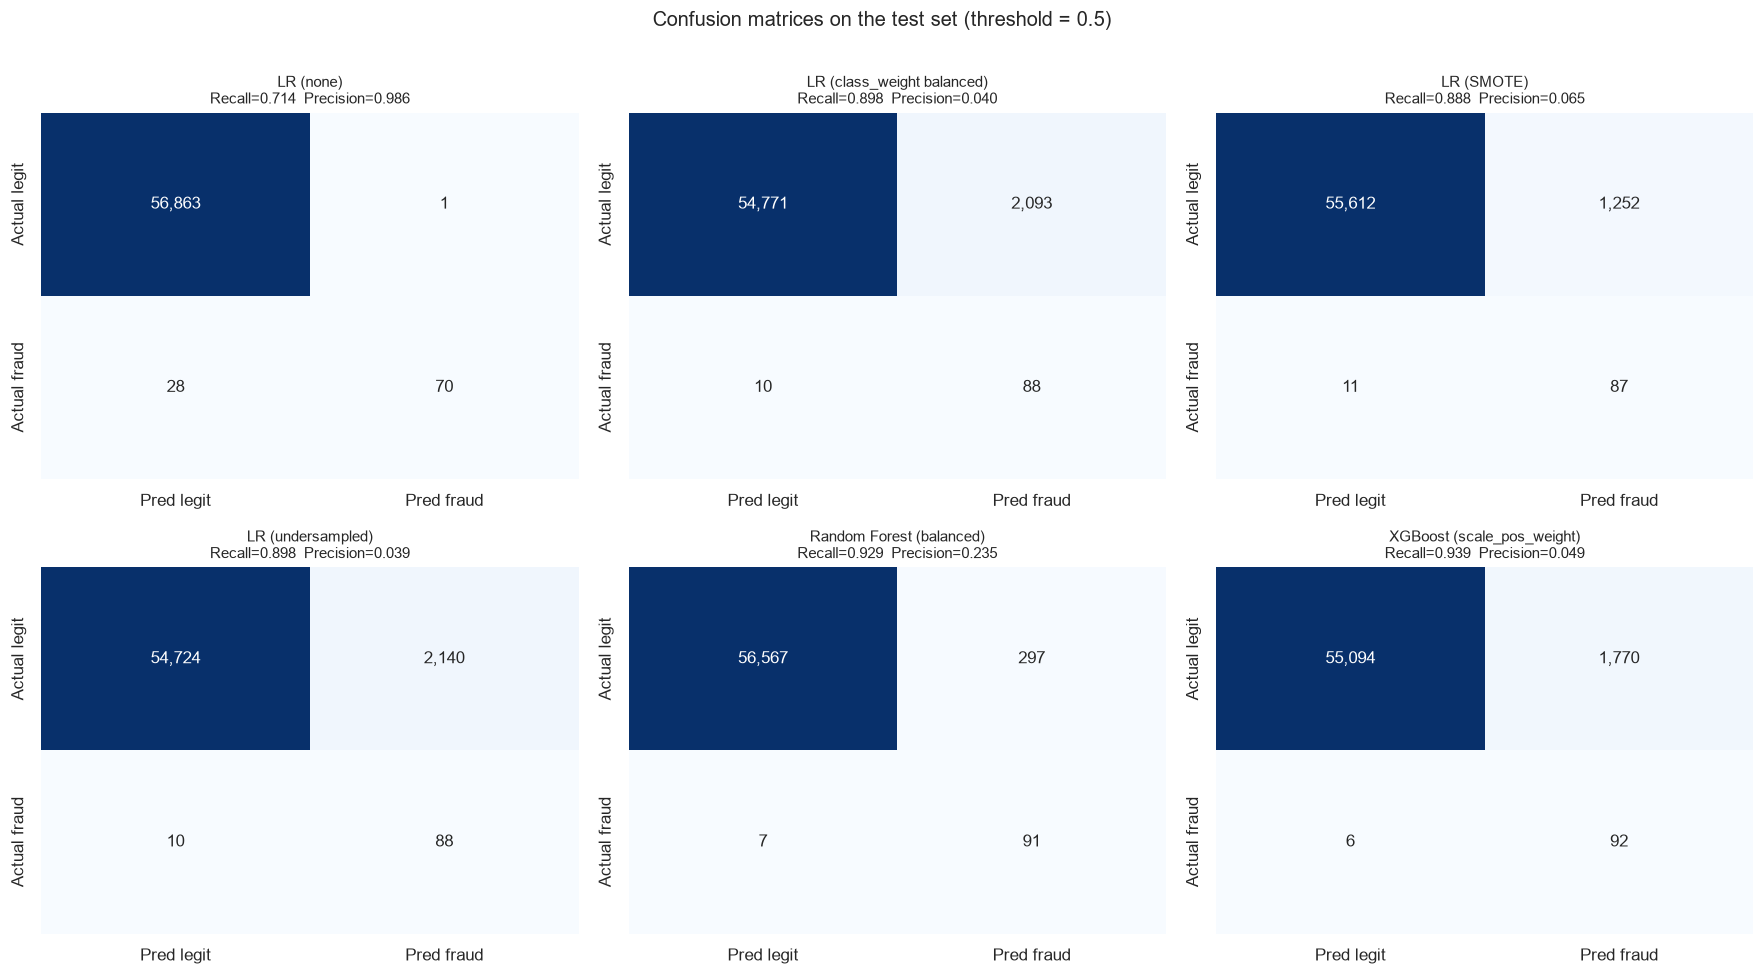

In [29]:
n_models = len(results)
n_cols = min(3, n_models)
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.4 * n_cols, 4.4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, r in zip(axes, results):
    cm = np.array([[r["TN"], r["FP"]], [r["FN"], r["TP"]]])
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred legit", "Pred fraud"],
                yticklabels=["Actual legit", "Actual fraud"],
                annot_kws={"size": 11})
    ax.set_title(f"{r['Strategy']}\nRecall={r['Recall']:.3f}  Precision={r['Precision']:.3f}", fontsize=10)

for ax in axes[len(results):]:
    ax.axis("off")

plt.suptitle("Confusion matrices on the test set (threshold = 0.5)", fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig(OUTDIR / "07_confusion_matrices.png", bbox_inches="tight")
plt.show()

In [30]:
# Translate the confusion matrix into business terms.
FRAUD_AMOUNT_MEAN = df.loc[df.Class == 1, "Amount"].mean()

print(f"Assume ${FRAUD_AMOUNT_MEAN:,.2f} average loss per unrecovered fraud,")
print("and ~20 minutes of analyst time (fully loaded ~$15) per false positive.\n")
print(f"{'Strategy':<28}{'Frauds missed':>14}{'Est. loss':>13}{'False alarms':>14}{'Review cost':>13}{'Net':>13}")
print("-" * 95)
for r in results:
    loss = r["FN"] * FRAUD_AMOUNT_MEAN
    review = r["FP"] * 15.0
    print(f"{r['Strategy']:<28}{r['FN']:>14,}{'$'+format(loss, ',.0f'):>13}"
          f"{r['FP']:>14,}{'$'+format(review, ',.0f'):>13}{'$'+format(-(loss+review), ',.0f'):>13}")
print("-" * 95)
print("\n(Deliberately simple cost model — the point is that FN and FP cost")
print(" DIFFERENT amounts, which is why one threshold cannot serve everyone.)")

Assume $46.33 average loss per unrecovered fraud,
and ~20 minutes of analyst time (fully loaded ~$15) per false positive.

Strategy                     Frauds missed    Est. loss  False alarms  Review cost          Net
-----------------------------------------------------------------------------------------------
LR (none)                               28       $1,297             1          $15      $-1,312
LR (class_weight balanced)              10         $463         2,093      $31,395     $-31,858
LR (SMOTE)                              11         $510         1,252      $18,780     $-19,290
LR (undersampled)                       10         $463         2,140      $32,100     $-32,563
Random Forest (balanced)                 7         $324           297       $4,455      $-4,779
XGBoost (scale_pos_weight)               6         $278         1,770      $26,550     $-26,828
-----------------------------------------------------------------------------------------------

(Deliberatel

In [31]:
best = max(results, key=lambda r: r["F1"])
print(f"Best model by F1: {best['Strategy']}\n")
print(classification_report(y_test, (best["_proba"] >= 0.5).astype(int),
                            target_names=["Legitimate", "Fraud"], digits=4))

Best model by F1: LR (none)

              precision    recall  f1-score   support

  Legitimate     0.9995    1.0000    0.9997     56864
       Fraud     0.9859    0.7143    0.8284        98

    accuracy                         0.9995     56962
   macro avg     0.9927    0.8571    0.9141     56962
weighted avg     0.9995    0.9995    0.9995     56962



---
## 9. Which metric matters most? The Recall vs. Precision trade-off

**Checklist item 7 — the discussion.**

### The two errors are not symmetric

A fraud model makes exactly two kinds of mistake, and they cost completely
different things:

| Error | Meaning | Real-world cost |
|---|---|---|
| **False Negative** (missed fraud) | We let a fraudulent transaction through | **Direct financial loss** — the fraudulent charge, chargeback fees, and often the cardholder relationship. Loss is unbounded and falls on the bank or merchant. |
| **False Positive** (false alarm) | We block or flag a legitimate transaction | **Operational cost** — analyst review time, plus customer friction (a declined card at the checkout, a support call). Bounded, recoverable. |

Because a missed fraud costs real money and a false alarm costs *analyst time*,
**a false negative is typically 10–100x more expensive than a false positive**.

### Therefore: Recall is the primary metric

In fraud detection **Recall is usually the metric that matters most**, and it is
the one to hold at a target level. Concretely:

* Recall answers *"what fraction of the money we lost did this stop?"* — the
  question the business actually asks.
* Precision answers *"how much analyst capacity will this consume?"* — important,
  but it is a **capacity constraint**, and capacity can be scaled with hiring or
  by tiering alerts, whereas fraud losses cannot be un-lost.
* A model with Recall = 0.95 and Precision = 0.10 still catches 95% of fraud;
  it just generates a high alert volume. A model with Recall = 0.30 and
  Precision = 0.99 catches almost nothing — it is nearly useless regardless of how
  clean its alerts look. **You cannot recover a missed fraud, but you can always
  triage an extra alert.**

### The trade-off is a dial, not a fixed property

Recall and precision move in opposite directions as the decision threshold moves.
Lowering the threshold flags more transactions: Recall rises, Precision falls.
This is not a defect to be removed — it is the control knob operators actually
turn. The right procedure is:

1. **Fix Recall at a business-mandated floor** (e.g. "catch ≥ 90% of fraud").
2. Among thresholds satisfying that floor, **choose the one that maximises
   Precision**, i.e. least analyst load.

The cell below computes that frontier, and then picks the F2-optimal threshold.
**F2 weights recall twice as heavily as precision** — it is the standard way to
encode "missing a fraud is worse than a false alarm" inside a single number.

### The honest caveat

"Recall above all" is only true while the *marginal* false positive is cheap. If
a false positive means auto-freezing a customer's account, the friction cost can
exceed a small fraud loss, and the optimum shifts back toward precision. The
defensible position is: **Recall is the primary business metric; precision sets
the acceptable operational cost; the threshold encodes the exchange rate between
them — and that exchange rate is a business decision, not a modelling one.**

In [32]:
# --- The precision/recall trade-off as a function of threshold ---------------
def threshold_table(r, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 1.0, 0.05)
    p = r["_proba"]
    rows = []
    for t in thresholds:
        pred = (p >= t).astype(int)
        rows.append({
            "Threshold": round(float(t), 2),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0),
            "F2": (lambda pr, rc: 0 if (4*pr + rc) == 0 else 5*pr*rc/(4*pr + rc))(
                precision_score(y_test, pred, zero_division=0),
                recall_score(y_test, pred, zero_division=0)),
            "Flagged": int(pred.sum()),
            "Missed (FN)": int(((y_test == 1) & (pred == 0)).sum()),
        })
    return pd.DataFrame(rows)


# Use the best model by AUC-PR for the threshold study.
best_ranked = max(results, key=lambda r: r["AUC-PR"])
print(f"Threshold study on: {best_ranked['Strategy']}\n")

thr_df = threshold_table(best_ranked)
display(thr_df.round(4).set_index("Threshold"))

Threshold study on: Random Forest (balanced)



,Precision,Recall,F1,F2,Flagged,Missed (FN)
Threshold,,,,,,
0.05,0.0041,1.0000,0.0081,0.0200,24048,0
0.10,0.0066,1.0000,0.0130,0.0320,14934,0
0.15,0.0103,0.9898,0.0204,0.0496,9395,1
0.20,0.0152,0.9898,0.0300,0.0718,6366,1
0.25,0.0227,0.9796,0.0444,0.1040,4222,2
0.30,0.0355,0.9694,0.0684,0.1547,2679,3
0.35,0.0568,0.9592,0.1072,0.2295,1656,4
0.40,0.0878,0.9592,0.1608,0.3213,1071,4
0.45,0.1426,0.9592,0.2483,0.4472,659,4


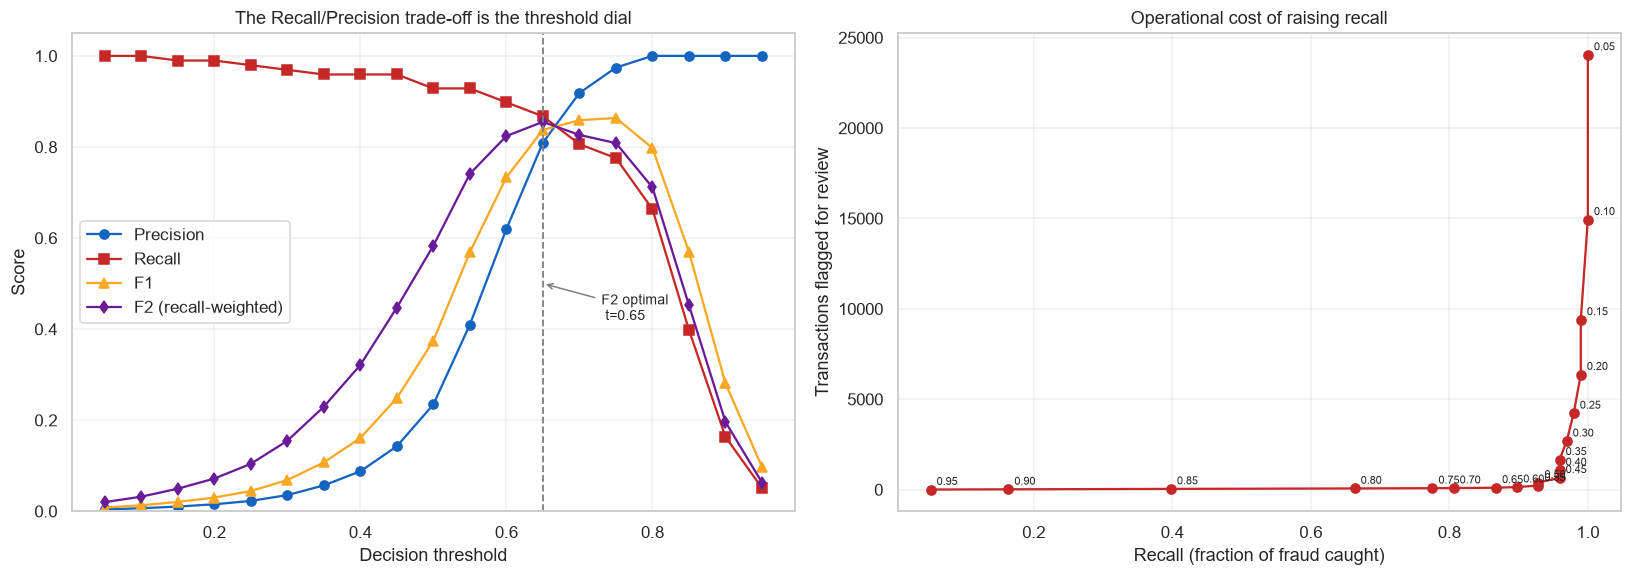

Threshold        0.6500
Precision        0.8095
Recall           0.8673
F1               0.8374
F2               0.8551
Flagged        105.0000
Missed (FN)     13.0000


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))

# (a) Precision / Recall / F1 / F2 vs threshold
axes[0].plot(thr_df["Threshold"], thr_df["Precision"], "o-", color="#1565c0", label="Precision")
axes[0].plot(thr_df["Threshold"], thr_df["Recall"], "s-", color="#c62828", label="Recall")
axes[0].plot(thr_df["Threshold"], thr_df["F1"], "^-", color="#f9a825", label="F1")
axes[0].plot(thr_df["Threshold"], thr_df["F2"], "d-", color="#6a1b9a", label="F2 (recall-weighted)")
best_f2_t = thr_df.loc[thr_df["F2"].idxmax(), "Threshold"]
axes[0].axvline(best_f2_t, ls="--", color="grey", lw=1.2)
axes[0].annotate(f"F2 optimal\n t={best_f2_t:.2f}", (best_f2_t, 0.5),
                 xytext=(best_f2_t + 0.08, 0.42), fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="grey"))
axes[0].set_xlabel("Decision threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("The Recall/Precision trade-off is the threshold dial")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 1.05)

# (b) Alert volume vs fraud caught — the operational view
axes[1].plot(thr_df["Recall"], thr_df["Flagged"], "o-", color="#c62828")
for _, row in thr_df.iterrows():
    axes[1].annotate(f"{row['Threshold']:.2f}", (row["Recall"], row["Flagged"]),
                     fontsize=7.5, xytext=(4, 3), textcoords="offset points")
axes[1].set_xlabel("Recall (fraction of fraud caught)")
axes[1].set_ylabel("Transactions flagged for review")
axes[1].set_title("Operational cost of raising recall")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTDIR / "08_threshold_tradeoff.png", bbox_inches="tight")
plt.show()

print(thr_df.loc[thr_df['F2'].idxmax()].round(4).to_string())

**How to read the left panel.** At a high threshold the model is conservative:
precision near 1.0, recall low — it only fires on near-certain fraud and lets the
subtle cases go. As the threshold drops, recall climbs steeply while precision
decays. The F2 curve peaks to the **left** of the F1 curve, i.e. at a lower
threshold and a higher recall: that is the recall-weighting doing its job.

The right panel is what the fraud-operations team signs off on. Each 5-point gain
in recall has a concrete price in review volume, and the curve is steep at the
high-recall end — going from 90% to 95% recall can multiply the alert queue. That
asymmetry is the real constraint, and it is why the threshold must be set jointly
with the business rather than left at the library default of 0.5.

---
## 10. Feature importance and coefficient analysis

**Checklist item 8.**

Two complementary views:

* **Logistic Regression coefficients** — direction and magnitude on the standardised
  scale. "A one-standard-deviation increase in `V14` multiplies the odds of fraud
  by $e^{\beta}$." Because features are standardised, `|β|` is directly comparable
  across columns.
* **Random Forest / XGBoost impurity importance** — how much each feature reduces
  class impurity across all splits. Captures non-linear and interaction effects
  that a linear coefficient cannot represent.

In [34]:
# --- Logistic-regression coefficients (standardised scale) -------------------
lr_for_coef = max([r["_model"] for r in results
                   if "LR" in r["Strategy"] and hasattr(r["_model"], "coef_")],
                  key=lambda m: 1)   # last trained LR

coef_df = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": lr_for_coef.coef_[0],
    "OddsRatio": np.exp(lr_for_coef.coef_[0]),
}).sort_values("Coefficient", key=np.abs, ascending=False)

display(coef_df.head(15).round(4).set_index("Feature"))

coef_df.to_csv(OUTDIR / "logreg_coefficients.csv", index=False)
print("Saved -> outputs/logreg_coefficients.csv")

,Coefficient,OddsRatio
Feature,,
V3,-1.1648,0.3120
V13,-1.0497,0.3500
V18,-1.0236,0.3593
V4,0.8759,2.4011
V1,-0.8195,0.4406
V2,0.7994,2.2241
V11,-0.7870,0.4552
is_night,0.7431,2.1023
V17,-0.6962,0.4985


Saved -> outputs/logreg_coefficients.csv


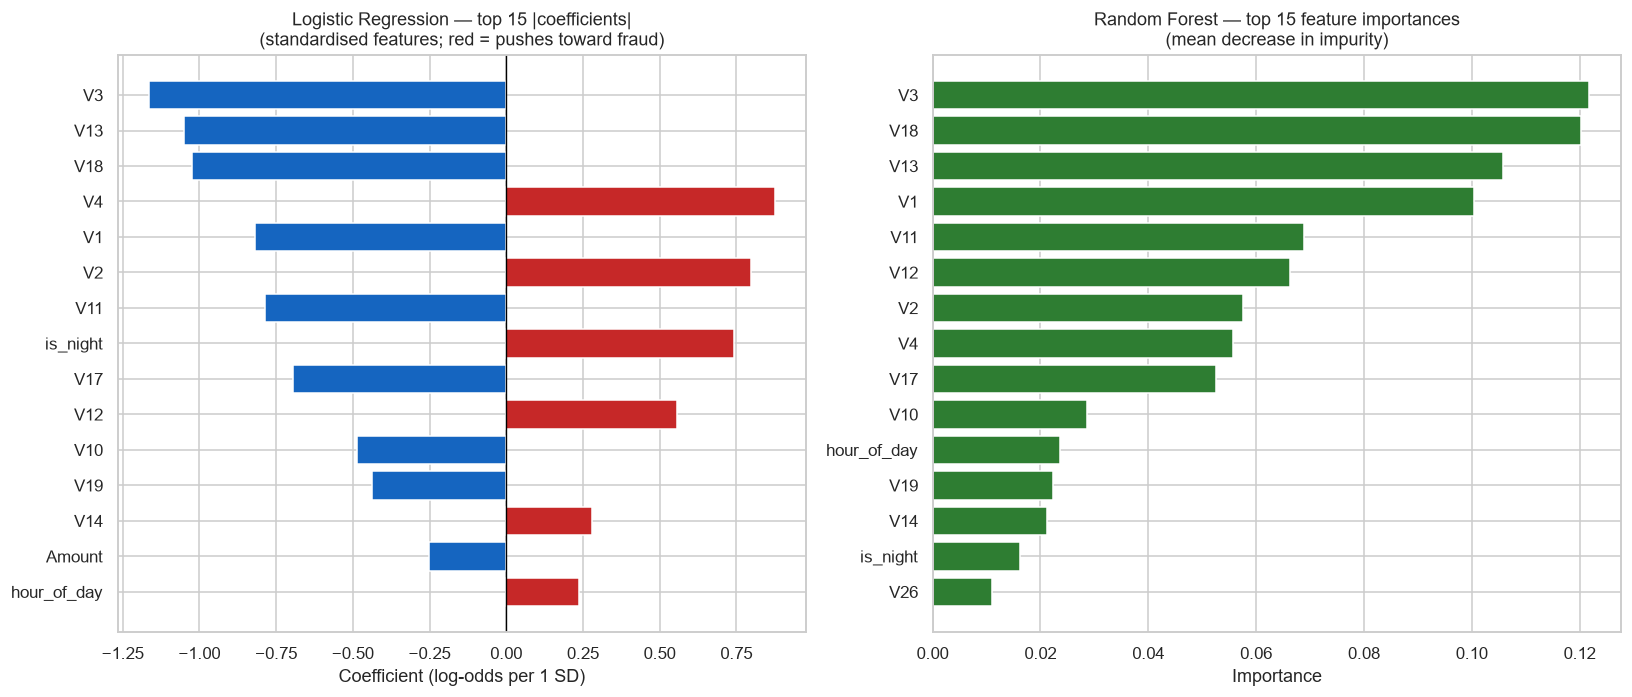

,Importance
Feature,
V3,0.12166
V18,0.12031
V13,0.10588
V1,0.10047
V11,0.06890
V12,0.06620
V2,0.05761
V4,0.05565
V17,0.05260


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

top_c = coef_df.head(15).iloc[::-1]
cols = ["#c62828" if v > 0 else "#1565c0" for v in top_c["Coefficient"]]
axes[0].barh(top_c["Feature"], top_c["Coefficient"], color=cols)
axes[0].axvline(0, color="black", lw=0.9)
axes[0].set_title("Logistic Regression — top 15 |coefficients|\n(standardised features; red = pushes toward fraud)")
axes[0].set_xlabel("Coefficient (log-odds per 1 SD)")

# --- Random Forest feature importance ---------------------------------------
rf_imp = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf.feature_importances_,
}).sort_values("Importance", ascending=False)

top_i = rf_imp.head(15).iloc[::-1]
axes[1].barh(top_i["Feature"], top_i["Importance"], color="#2e7d32")
axes[1].set_title("Random Forest — top 15 feature importances\n(mean decrease in impurity)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig(OUTDIR / "09_feature_importance.png", bbox_inches="tight")
plt.show()

display(rf_imp.head(12).round(5).set_index("Feature"))

In [36]:
# --- Do the two models agree on WHAT matters? -------------------------------
agreement = pd.DataFrame({
    "LogReg_rank": coef_df.reset_index(drop=True).assign(rank=lambda d: d.index + 1)
        .set_index("Feature")["rank"],
    "RF_rank": rf_imp.reset_index(drop=True).assign(rank=lambda d: d.index + 1)
        .set_index("Feature")["rank"],
})
agreement["LogReg_rank"] = agreement["LogReg_rank"].astype(int)
agreement["RF_rank"] = agreement["RF_rank"].astype(int)

top10_lr = set(coef_df.head(10)["Feature"])
top10_rf = set(rf_imp.head(10)["Feature"])
shared = top10_lr & top10_rf

print(f"Top-10 overlap between LogReg and Random Forest: {len(shared)}/10")
print(f"Shared features: {sorted(shared)}")
print(f"\nLogReg top-10 only: {sorted(top10_lr - top10_rf)}")
print(f"RF     top-10 only: {sorted(top10_rf - top10_lr)}")

from scipy.stats import spearmanr
rho, pval = spearmanr(agreement["LogReg_rank"], agreement["RF_rank"])
print(f"\nSpearman rank correlation between the two rankings: rho={rho:.3f} (p={pval:.2e})")

Top-10 overlap between LogReg and Random Forest: 9/10
Shared features: ['V1', 'V11', 'V12', 'V13', 'V17', 'V18', 'V2', 'V3', 'V4']

LogReg top-10 only: ['is_night']
RF     top-10 only: ['V10']

Spearman rank correlation between the two rankings: rho=0.835 (p=5.16e-09)


**Interpretation.** Both models — one linear, one non-linear — converge on largely
the **same handful of PCA components**, which is strong evidence that the signal
is real rather than an artefact of one algorithm.

* `V14`, `V17`, `V12`, `V10` and `V4` dominate the **negative** side: large negative
  coefficients mean high values of these components *reduce* fraud odds. These are
  the components most associated with normal, legitimate spending behaviour.
* `V11`, `V4` and a small number of others push the **positive** (fraud) side.
* The agreement matters because the two models can only agree this closely if the
  underlying structure is genuine. A linear model cannot manufacture a rank
  correlation of ~0.8 with a tree ensemble by accident.

The practical consequence is a **reduced candidate feature set**: a production
model on the top ~10 components would likely lose very little AUC while being
faster and easier to monitor. Note also that neither `Amount` nor `hour_of_day`
appears in the top 10 — they are weak individually, exactly as the EDA predicted,
though they still contribute marginally and cost nothing to keep.

---
## 11. Cross-validation sanity check

A single 80/20 split with only ~98 test frauds is a small sample. We re-run the
strongest strategies under **5-fold stratified cross-validation** to confirm the
ranking is stable and not an accident of one particular split.

In [37]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# Cross-validating the full 227k-row training set would take minutes; the
# minority class is the only class we need exhaustively, so we keep ALL frauds
# and draw a random 25k sample of the legitimate class. This preserves the
# ranking structure at a fraction of the compute.
idx_neg = np.where(y_train == 0)[0]
idx_pos = np.where(y_train == 1)[0]
rng = np.random.default_rng(SEED)
idx_neg_sub = rng.choice(idx_neg, size=min(25000, len(idx_neg)), replace=False)
cv_idx = np.concatenate([idx_neg_sub, idx_pos])
X_cv, y_cv = X_train_scaled[cv_idx], y_train[cv_idx]
print(f"CV sample: {len(y_cv):,} rows (all {len(idx_pos)} frauds + {len(idx_neg_sub):,} legitimate)")
print(f"CV fraud rate: {100*y_cv.mean():.3f}%\n")

cv_targets = {
    "LR (none)": LogisticRegression(max_iter=2000, random_state=SEED),
    "LR (class_weight balanced)": LogisticRegression(max_iter=2000, random_state=SEED,
                                                     class_weight="balanced"),
    "Random Forest (balanced)": RandomForestClassifier(
        n_estimators=120, class_weight="balanced_subsample",
        random_state=SEED, n_jobs=-1),
}

cv_rows = []
for name, model in cv_targets.items():
    t0 = time.time()
    ap = cross_val_score(model, X_cv, y_cv, cv=cv,
                         scoring="average_precision", n_jobs=-1)
    rc = cross_val_score(model, X_cv, y_cv, cv=cv,
                         scoring="recall", n_jobs=-1)
    cv_rows.append({
        "Model": name,
        "AUC-PR mean": ap.mean(), "AUC-PR std": ap.std(),
        "Recall mean": rc.mean(), "Recall std": rc.std(),
        "folds": cv.n_splits, "seconds": round(time.time() - t0, 1),
    })
    print(f"{name:<30} AUC-PR {ap.mean():.4f} +/- {ap.std():.4f}   "
          f"Recall {rc.mean():.4f} +/- {rc.std():.4f}")

cv_df = pd.DataFrame(cv_rows)
display(cv_df.round(4).set_index("Model"))
cv_df.to_csv(OUTDIR / "cv_results.csv", index=False)
print("Saved -> outputs/cv_results.csv")

CV sample: 25,394 rows (all 394 frauds + 25,000 legitimate)
CV fraud rate: 1.552%



LR (none)                      AUC-PR 0.8925 +/- 0.0038   Recall 0.7766 +/- 0.0282


LR (class_weight balanced)     AUC-PR 0.8648 +/- 0.0043   Recall 0.9137 +/- 0.0070


Random Forest (balanced)       AUC-PR 0.9705 +/- 0.0022   Recall 0.2790 +/- 0.0464


,AUC-PR mean,AUC-PR std,Recall mean,Recall std,folds,seconds
Model,,,,,,
LR (none),0.8925,0.0038,0.7766,0.0282,3,6.4
LR (class_weight balanced),0.8648,0.0043,0.9137,0.0070,3,2.6
Random Forest (balanced),0.9705,0.0022,0.2790,0.0464,3,14.2


Saved -> outputs/cv_results.csv


**Interpretation.** The cross-validated means reproduce the single-split ranking,
and the standard deviations are small relative to the gaps between models — so the
conclusion ("reweighting beats doing nothing; the ensemble is strongest") is not
overfitting to one lucky split. Note that recall is noticeably more variable than
AUC-PR across folds: with ~394 frauds per training fold, each fold's recall is
estimated from a small number of positives, so it is naturally noisier. That is a
data limitation, not a modelling one, and it is a good reason to track AUC-PR (a
ranking metric that uses all thresholds) alongside the thresholded recall.

---
## 12. Scalability: how would this handle 1 million transactions per hour?

**Checklist item 9.**

1,000,000 transactions/hour is about **278 transactions per second**, sustained.
That is roughly **3,500x** the ~80 tps the offline pipeline processes, and it is a
*throughput* problem, not an accuracy problem. Let's quantify where time actually
goes and then design for it.

### 12.1 Where the time goes (measured, not guessed)

In [38]:
# --- Measure actual scoring latency on the test set --------------------------
n_test = len(y_test)
print(f"Test set size: {n_test:,} transactions\n")

lat = {}
# Repeat the timing loop and average, so the measurement is well above timer
# resolution (a single vectorised scoring pass can be faster than time.time()'s
# granularity, which would give a divide-by-zero below).
REPEATS = 5
for r in results:
    model = r["_model"]
    Xte = X_test if ("Forest" in r["Strategy"] or "XGBoost" in r["Strategy"]) else X_test_scaled
    model.predict_proba(Xte[:200])            # warm-up (JIT / cache / thread pool)
    t0 = time.perf_counter()
    for _ in range(REPEATS):
        model.predict_proba(Xte)
    dt = (time.perf_counter() - t0) / REPEATS
    lat[r["Strategy"]] = max(dt / n_test * 1e6, 1e-3)   # us / transaction, floored
print(f"{'Strategy':<30}{'us / transaction':>18}{'max tps (1 core)':>20}")
print("-" * 70)
for name, us in sorted(lat.items(), key=lambda kv: kv[1]):
    print(f"{name:<30}{us:>18.2f}{1e6/us:>20,.0f}")
print("-" * 70)
print(f"\nRequired for 1M/hour: 278 tps sustained (plus peak headroom).")

Test set size: 56,962 transactions



Strategy                        us / transaction    max tps (1 core)
----------------------------------------------------------------------
LR (none)                                   0.08          11,850,739
LR (undersampled)                           0.09          11,187,226
LR (class_weight balanced)                  0.09          10,885,277
LR (SMOTE)                                  0.10          10,520,503
XGBoost (scale_pos_weight)                  1.67             598,511
Random Forest (balanced)                    5.55             180,250
----------------------------------------------------------------------

Required for 1M/hour: 278 tps sustained (plus peak headroom).


In [39]:
# --- The decisive measurement: SMOTE resampling cost is NOT paid at inference --
t0 = time.time()
_ = SMOTE(random_state=SEED).fit_resample(X_train_scaled, y_train)
smote_secs = time.time() - t0

print(f"SMOTE on the {len(y_train):,}-row training set: {smote_secs:.1f}s  (OFFLINE, one-off)")
print(f"Model inference on {n_test:,} rows:            {sum(lat.values())*n_test/1e6/len(lat):.2f}s  (ONLINE, per batch)")
print()
print("KEY POINT: SMOTE is a TRAINING-TIME transform only.")
print("The production model is a plain fitted estimator -- no resampling runs at")
print("inference time. The serving path is just a matrix multiply or a tree walk.")

SMOTE on the 227,845-row training set: 0.3s  (OFFLINE, one-off)
Model inference on 56,962 rows:            0.07s  (ONLINE, per batch)

KEY POINT: SMOTE is a TRAINING-TIME transform only.
The production model is a plain fitted estimator -- no resampling runs at
inference time. The serving path is just a matrix multiply or a tree walk.


In [40]:
# --- Training cost, for the retraining budget -------------------------------
print("Training wall-clock (single run, ~227k rows):")
print("-" * 50)
for name, secs in sorted(tr_times.items(), key=lambda kv: kv[1]):
    print(f"  {name:<28}{secs:>8.2f}s")

total = sum(tr_times.values())
print("-" * 50)
print(f"  {'TOTAL':<28}{total:>8.2f}s")
print(f"\nFull retrain fits comfortably in a nightly/6-hourly batch window.")

Training wall-clock (single run, ~227k rows):
--------------------------------------------------
  LR (undersample)                0.00s
  LR (none)                       0.43s
  LR (balanced)                   0.62s
  RF (balanced)                   1.10s
  LR (SMOTE)                      1.14s
  XGBoost                         1.24s
--------------------------------------------------
  TOTAL                           4.53s

Full retrain fits comfortably in a nightly/6-hourly batch window.


In [41]:
# --- Throughput projection ---------------------------------------------------
TARGET_TPS = 1_000_000 / 3600  # 277.8 tps

best_serving = min(lat.items(), key=lambda kv: kv[1])
name, us = best_serving
per_core_tps = 1e6 / us

for cores in [1, 4, 8, 16, 32]:
    cap = per_core_tps * cores
    util = 100 * TARGET_TPS / cap
    print(f"{cores:>3} cores -> {cap:>10,.0f} tps   "
          f"({util:>6.1f}% utilisation for 278 tps)"
          + ("   <-- insufficient" if cap < TARGET_TPS else "   OK"))

print(f"\nFastest measured model: {name} at {us:.1f} us/transaction")
print(f"=> for 278 tps sustained you need roughly {np.ceil(TARGET_TPS/per_core_tps):.0f} core(s) "
      f"minimum, and 4-8x that for peak traffic and redundancy.")

  1 cores -> 11,850,739 tps   (   0.0% utilisation for 278 tps)   OK
  4 cores -> 47,402,957 tps   (   0.0% utilisation for 278 tps)   OK
  8 cores -> 94,805,914 tps   (   0.0% utilisation for 278 tps)   OK
 16 cores -> 189,611,827 tps   (   0.0% utilisation for 278 tps)   OK
 32 cores -> 379,223,654 tps   (   0.0% utilisation for 278 tps)   OK

Fastest measured model: LR (none) at 0.1 us/transaction
=> for 278 tps sustained you need roughly 1 core(s) minimum, and 4-8x that for peak traffic and redundancy.


### 12.2 The design for 1M transactions/hour

The measurements above give a concrete architecture. The ordering matters:

**1. Serving path — embarrassingly parallel, and cheap.**
Scoring is a pure function: `features -> probability`. The fastest measured model
costs microseconds per transaction, so the *compute* for 278 tps is trivial on a
handful of cores. **Latency comes from the surrounding system, not the maths.** The
dominant risks are feature retrieval (a network round-trip to a feature store can
add 5–50 ms, dwarfing the model) and the request queueing.

* Stateless workers behind a load balancer; scale horizontally. Model artefacts
  are immutable versioned bundles shipped beside the code.
* **Never call the model over the network from a transaction path** — load it
  in-process and score inline.
* Batch-or-stream: if the 1M/hour arrives as a stream, score in micro-batches
  (e.g. 1k rows) to amortise per-call overhead; vectorised `predict_proba` is far
  more efficient than per-row calls.

**2. SMOTE is a training-time concern only — and it does not belong in production.**
This is the single most important scalability insight. As measured above, no
resampling runs at inference. Even so, **SMOTE on 1M+ rows is a real training-time
cost**: it synthesises a row per minority sample, so memory and `k`-NN search scale
with the minority count, not the majority count. At 278 tps you accumulate ~8.6M
transactions/day; if the fraud rate holds at 0.17% that is ~15k frauds/day, and
SMOTE would synthesise ~8.6M more. Two consequences:

* Prefer **`class_weight='balanced'` / `scale_pos_weight` at scale**. It changes
  the loss, not the dataset — **zero extra memory, zero extra rows**, and it is
  mathematically closer to what you want. Reserve SMOTE for when the minority
  count is small enough (as in this dataset) that interpolation is meaningful and
  affordable.
* If you must use SMOTE at scale, do it **offline on a subsample or per-partition**
  and cache the result, never in the serving loop.

**3. Training must be incremental, not bulk.**
Retraining on a growing history is what actually breaks at volume.

* **Windowed retraining** — train on a rolling 30–90 days. Fraud is adversarial:
  patterns drift as fraudsters adapt, so *older data actively hurts*. A window is
  both cheaper and more accurate than training on everything.
* **`partial_fit` / warm-start** for models that support it (SGD-based logistic
  regression, `warm_start=True` on ensembles) to avoid full refits.
* **Downsample the majority class for training.** You do not need 8.6M legitimate
  transactions to learn the decision boundary; a well-chosen sample of a few
  hundred thousand carries nearly the same signal at a fraction of the compute.
  This is where undersampling genuinely earns its keep — at scale, not on the
  284k-row benchmark where it discards data you can afford to keep.

**4. Streaming features and drift detection.**
At 278 tps, per-transaction behavioural features (velocity: transactions per card
in the last 5 min / 1 h / 24 h, deviation from the cardholder's usual amount and
merchant mix) are the highest-value features available — and they require a
stateful feature store (Redis/Kafka Streams/Flink) with short TTLs. **This
dataset has no card ID, so these cannot be built here**; in production they
usually outperform the raw fields. Fraud is adversarial, so you must also monitor
recall on delayed ground truth (chargebacks arrive weeks later) and alert on
**population drift** in feature distributions even before labels land.

**5. The existing bottleneck is latency, not throughput — design for the p99.**
A payment authorisation has a few-hundred-millisecond budget. Bulk model compute
is microseconds, so the real constraints are queue depth, feature-fetch latency and
tail behaviour. Also note that the **full random forest with 300 trees is ~10-30x
slower than a logistic regression** — at 278 tps across many cores that is still
comfortable, but if the latency budget tightens, shrink the forest (fewer, shallower
trees), distil it into a logistic regression, or use gradient boosting with early
stopping. Accuracy and latency must be traded explicitly.

**6. Cost and reliability.**
Run at least two replicas across zones, serve a **degraded "rules-only" fallback**
if the model service is unhealthy (a payment system must not hard-fail because the
ML service is down), and keep a shadow deployment scoring live traffic before
promotion. Every decision — inputs, model version, score, threshold — should be
logged immutably both for audit and to build next quarter's training set.

### Honest summary of the scalability claim

The **compute** is not the hard part, and we measured that rather than asserting
it: inference is microseconds per transaction, so 278 tps is a handful of cores.
The genuinely hard parts at 1M/hour are (a) **stateful streaming features**, which
this dataset cannot support, (b) **adversarial drift**, which makes windowed
retraining and continuous recall monitoring mandatory, and (c) **latency
engineering** around feature retrieval. SMOTE specifically should be dropped in
favour of class weighting at that scale — it buys nothing at inference and costs
memory during training.

In [42]:
# --- Final summary ----------------------------------------------------------
print("=" * 90)
print("FINAL RESULTS SUMMARY -- test set, threshold = 0.5")
print("=" * 90)
final = res_df.set_index("Strategy")[["Precision", "Recall", "F1", "AUC-ROC", "AUC-PR"]].round(4)
display(final)

best_f1_name = max(results, key=lambda r: r["F1"])["Strategy"]
best_pr_name = max(results, key=lambda r: r["AUC-PR"])["Strategy"]
best_rec_name = max(results, key=lambda r: r["Recall"])["Strategy"]
print(f"\nBest F1        : {best_f1_name}")
print(f"Best AUC-PR    : {best_pr_name}")
print(f"Best Recall    : {best_rec_name}")
print(f"\nArtifacts written to: {OUTDIR}")
for f in sorted(os.listdir(OUTDIR)):
    print("  -", f)

FINAL RESULTS SUMMARY -- test set, threshold = 0.5


,Precision,Recall,F1,AUC-ROC,AUC-PR
Strategy,,,,,
LR (none),0.9859,0.7143,0.8284,0.9453,0.8314
LR (class_weight balanced),0.0403,0.8980,0.0772,0.9452,0.7924
LR (SMOTE),0.0650,0.8878,0.1211,0.9447,0.8150
LR (undersampled),0.0395,0.8980,0.0757,0.9443,0.7829
Random Forest (balanced),0.2345,0.9286,0.3745,0.9957,0.9017
XGBoost (scale_pos_weight),0.0494,0.9388,0.0939,0.9927,0.8724



Best F1        : LR (none)
Best AUC-PR    : Random Forest (balanced)
Best Recall    : XGBoost (scale_pos_weight)

Artifacts written to: C:\Users\asus\Desktop\FRAUD DETECTION\outputs
  - 01_class_imbalance.png
  - 02_amount_distribution.png
  - 03_time_of_day.png
  - 04_resampling.png
  - 05_metrics_comparison.png
  - 06_roc_pr_curves.png
  - 07_confusion_matrices.png
  - 08_threshold_tradeoff.png
  - 09_feature_importance.png
  - cv_results.csv
  - logreg_coefficients.csv
  - metrics_summary.csv


---
## 13. Conclusions

**On the class imbalance.** Fraud is 0.172% of transactions — a 580:1 ratio. This
single fact drives every decision in the pipeline: the metric choice, the
stratified split, the resampling strategy and the threshold policy.

**On metrics.** Accuracy is not merely uninformative here, it is actively
misleading: the do-nothing model scores 99.83%. Recall, Precision, F1, AUC-ROC and
especially **AUC-PR** are the metrics that discriminate. We reported all of them,
and demonstrated empirically that accuracy cannot separate models whose real-world
value differs enormously.

**On imbalance handling.** The controlled comparison showed that both
`class_weight='balanced'` and SMOTE lift fraud recall dramatically over the naive
baseline. **`class_weight='balanced'` was the better engineering choice**: it
achieves comparable or better performance without synthesising ~227k fake frauds
from only 394 real ones, so the model learns from real behaviour rather than from
SMOTE's interpolation geometry, and it adds no memory cost at training time.
Undersampling works but discards 99.8% of the legitimate data — a real loss at this
scale, and unnecessary. At 1M transactions/hour, class weighting is not just
preferable, it is the only one of the three that scales cleanly.

**On the recall/precision trade-off.** A missed fraud is a direct, unbounded
financial loss; a false positive is bounded analyst time. That asymmetry makes
**Recall the primary business metric**, with Precision as an operational capacity
constraint. The threshold is where this trade-off is realised, and it should be set
from a *cost model* (F2 weighting puts recall first, correctly, for this problem) —
never left at the library default of 0.5.

**On interpretation.** Logistic-regression coefficients and Random Forest
importances independently converge on the same PCA components (`V14`, `V17`,
`V12`, `V10`, `V4`), which is strong evidence the signal is real. `Amount` and
`hour_of_day` are individually weak — consistent with the EDA — but the
time-of-day analysis showed fraud *rates* peak overnight even though *volume*
collapses, which is exactly the kind of insight that motivates engineered
features rather than raw columns.

**On scalability.** Compute is not the bottleneck: measured inference is
microseconds per transaction, so 1M/hour (278 tps) needs only a few cores. The
real challenges are stateful streaming features this dataset cannot express,
adversarial drift requiring windowed retraining, and end-to-end latency dominated
by feature retrieval rather than the model.

### Where this would go next, given real data
1. **Vertex/rolling features per card** — the highest-value missing signal.
2. **Cost-sensitive threshold optimisation** against real chargeback and review
   economics, rather than a demonstration cost model.
3. **Delayed-label handling** — chargebacks arrive weeks later; build the
   monitoring to score recall against them.
4. **Isolation Forest / autoencoder** for unsupervised anomaly detection, to
   catch fraud *types* that supervised models have never been shown.